## RB visualizer DEF

/home/me/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


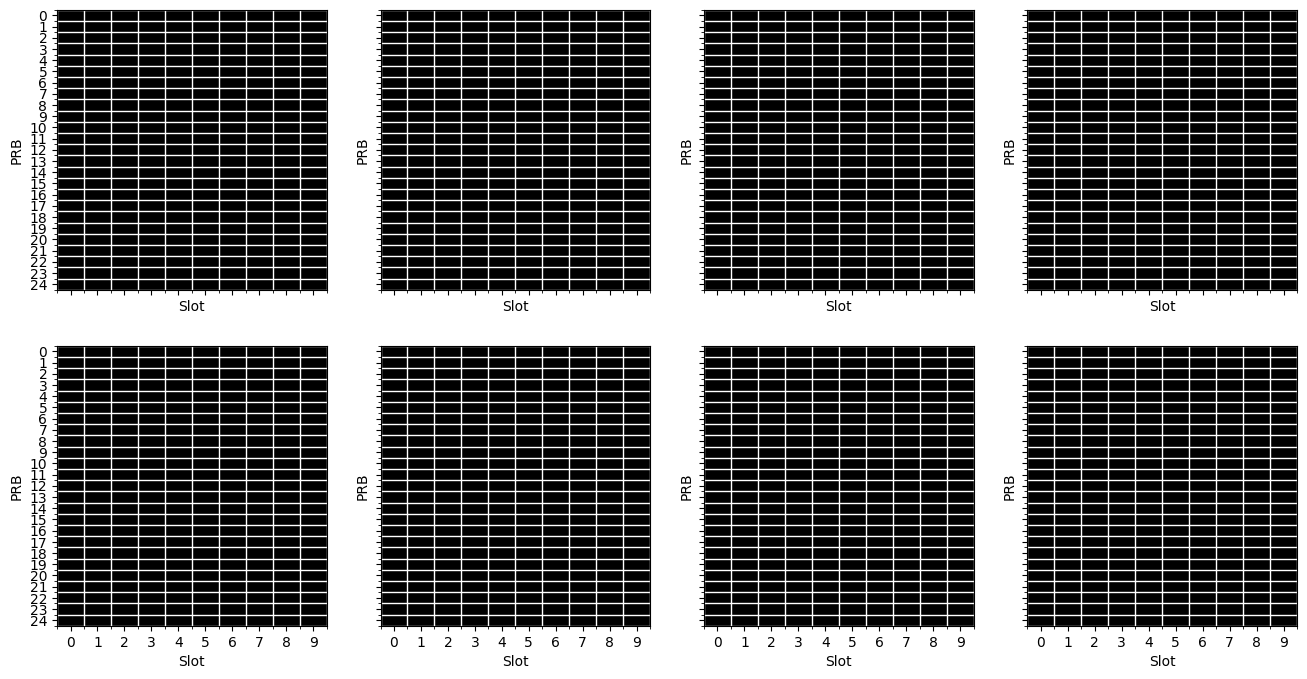

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import clear_output, display


# —— COLOR MAPPING —— 
label_to_int = {"business":0, "performance":1, "critical":2}
colors      = ["green","cyan","red","black"]   # last = “none”
cmap        = ListedColormap(colors)
T= 10
K=25
def alloc_df_to_grid(df):
    """Turn allocation_df with columns ['Slot','PRB','Slice'] into a 10×25 DataFrame of labels."""
    grid = np.full((T, K), np.nan, dtype=object)
    for _, r in df.iterrows():
        # r.Slice ∈ {1,2,3} → map 1→"critical", 2→"performance", 3→"business"
        lbl = {1:"critical", 2:"performance", 3:"business"}.get(r.Slice, np.nan)
        grid[int(r.Slot), int(r.PRB)] = lbl
    return pd.DataFrame(grid, index=range(T), columns=range(K))

# —— SETUP FIGURE ONCE (8 methods) —— 
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()
images = []
for ax in axes:
    # start all black
    init = np.full((K, T), 3, dtype=int)
    im = ax.imshow(init, aspect="auto", cmap=cmap, vmin=0, vmax=3)
    ax.set_xticks(np.arange(T))
    ax.set_yticks(np.arange(K))
    ax.set_xlabel("Slot")
    ax.set_ylabel("PRB")
    ax.grid(which="minor", color="w", linewidth=1)
    ax.set_xticks(np.arange(-.5, T, 1), minor=True)
    ax.set_yticks(np.arange(-.5, K, 1), minor=True)
    images.append(im)



## GRID

In [2]:
from IPython.display import display, clear_output
from ipywidgets import Output

# Create one Output widget for grids:
grid_out = Output()
display(grid_out)


# this is to remeove the cell outptut warning

import warnings

# Hide all FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Or more narrowly, only suppress that specific replace‐downcasting message:
warnings.filterwarnings(
    "ignore",
    message=".*Downcasting behavior in `replace` is deprecated.*"
)

Output()

# Main

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[RL Training][DQN] Skipped. Will load checkpoint: dqn_q_net.pth
Loaded trained DQN network for inference!
[RL Training][PPO] Skipped. Will load checkpoint: ppo_adss_checkpoint.pth
Loaded trained PPO network for inference!


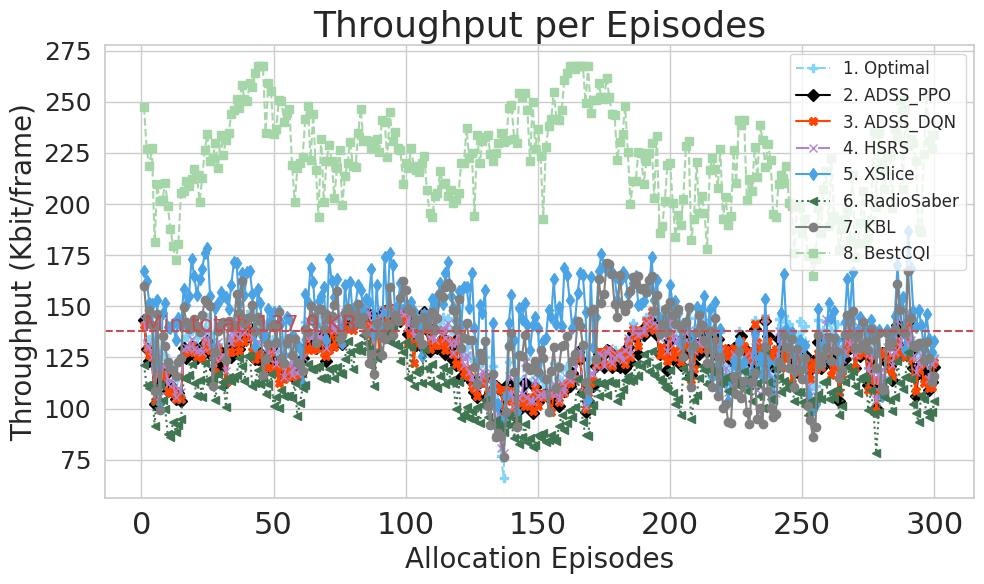

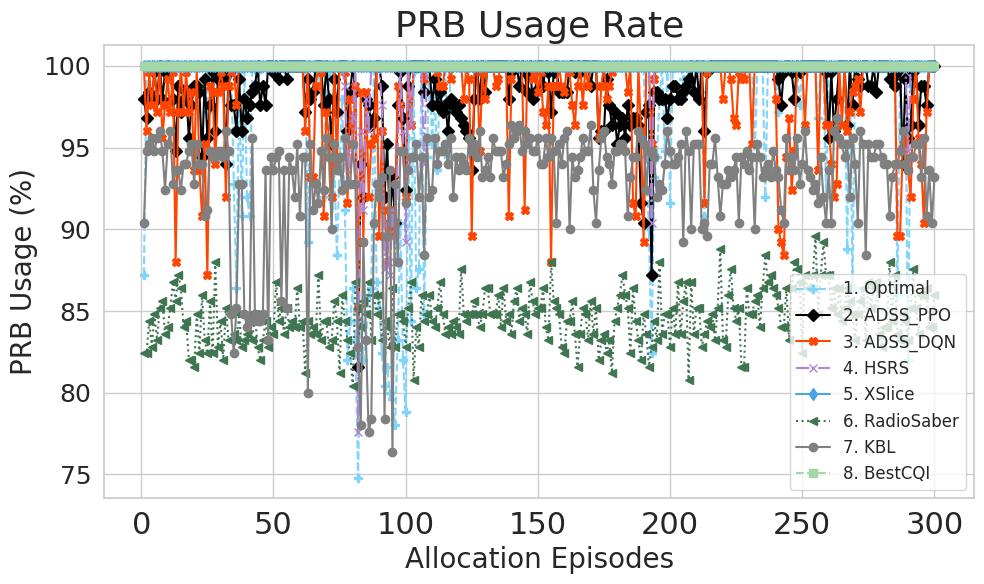

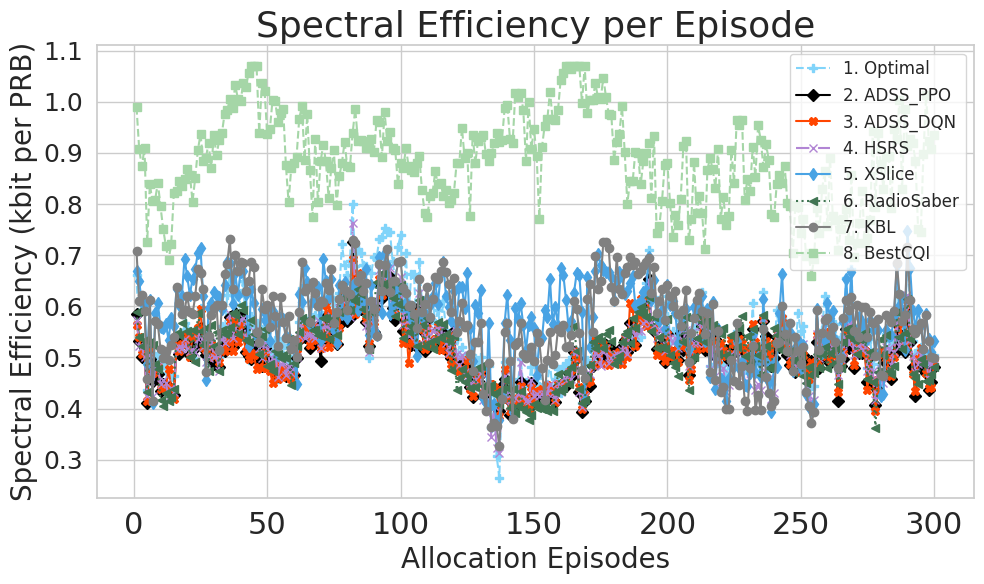

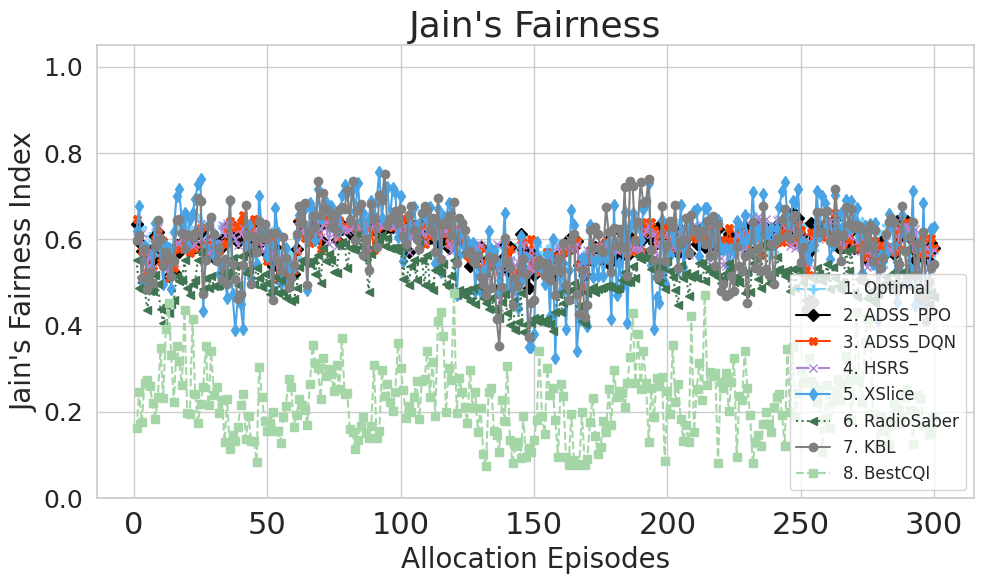

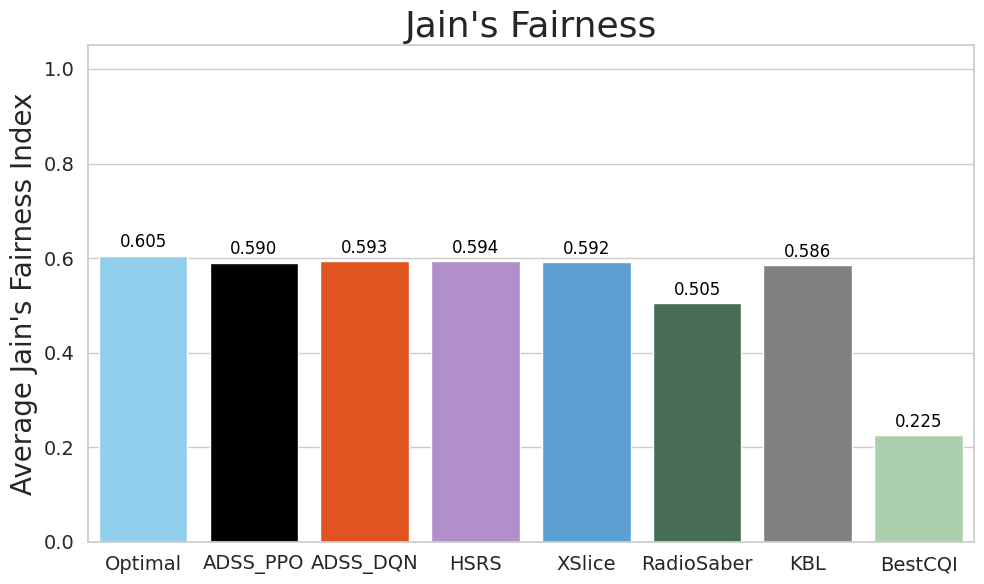

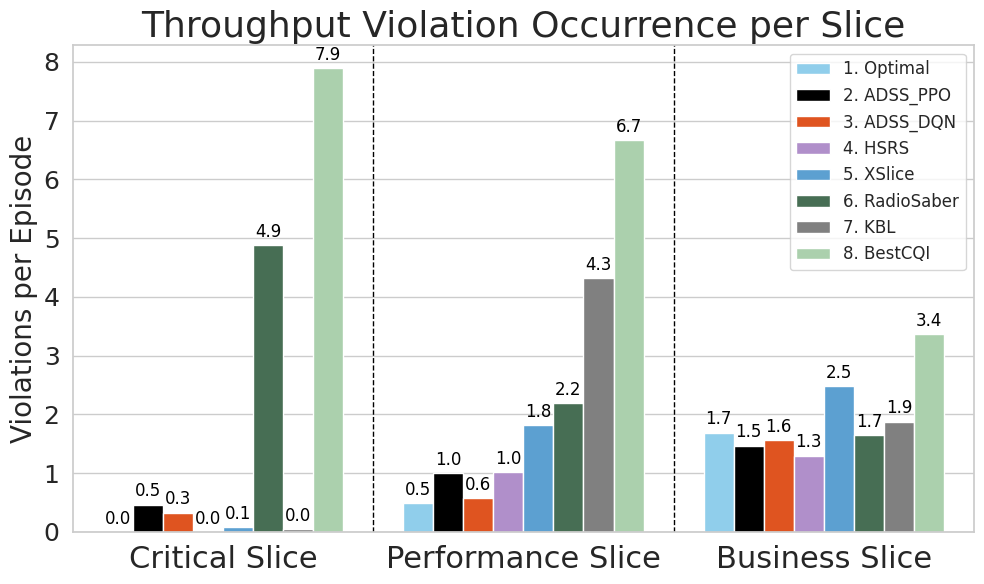

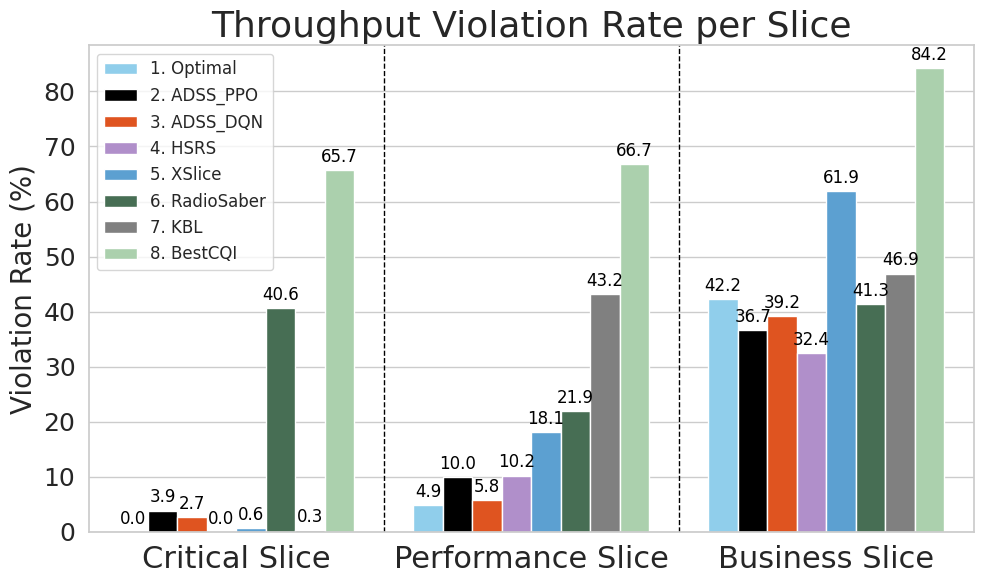

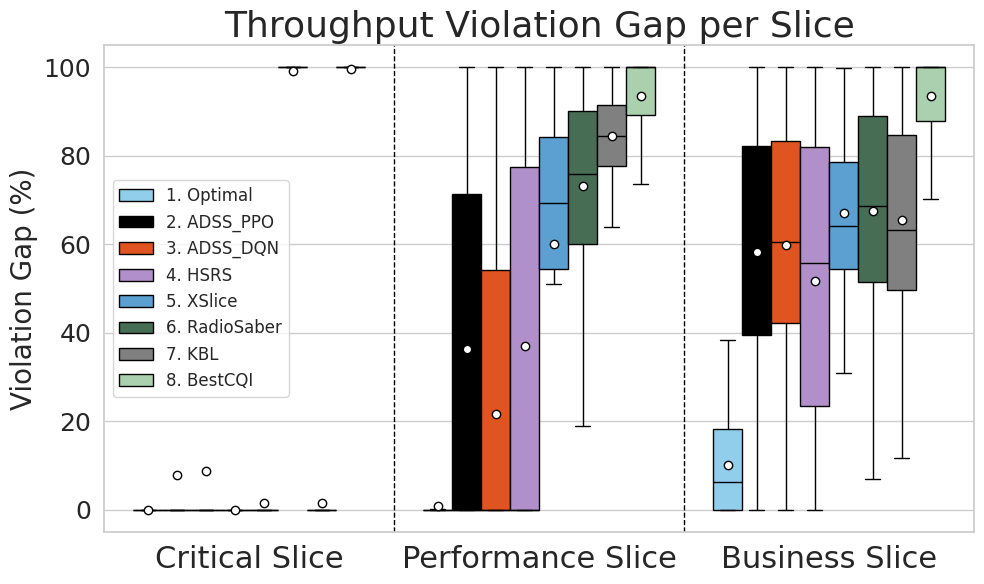

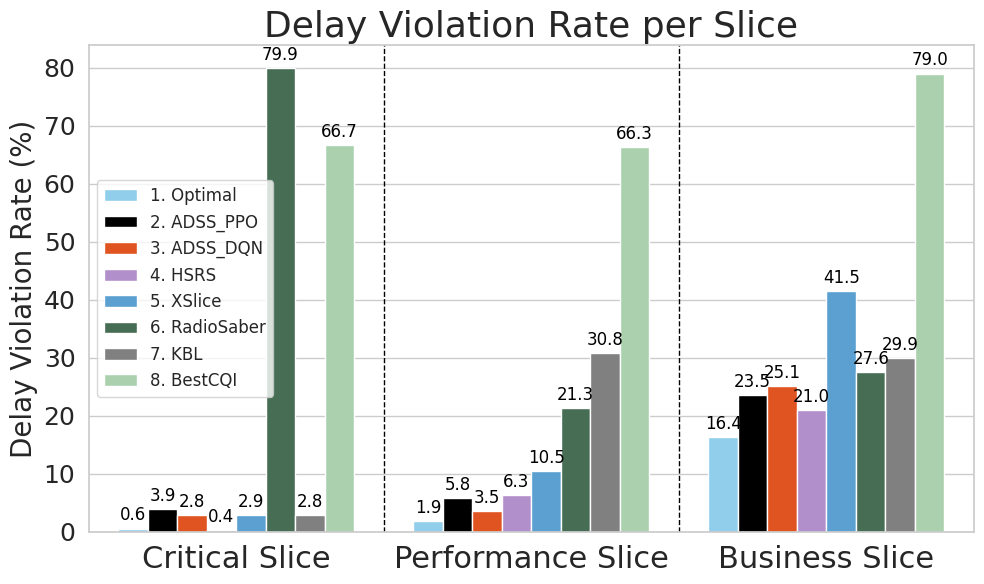

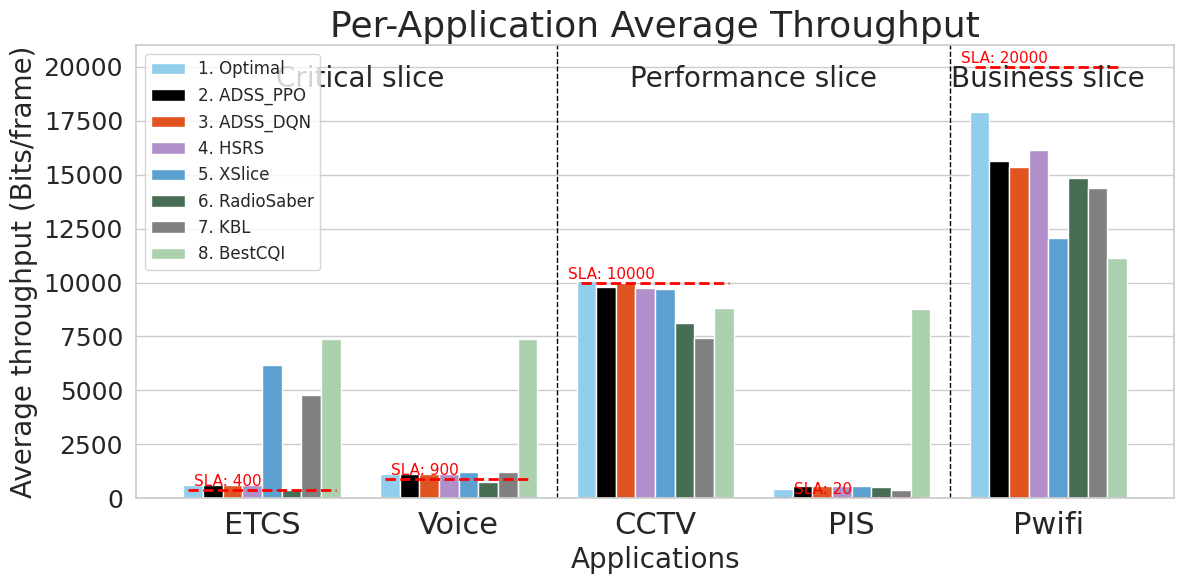

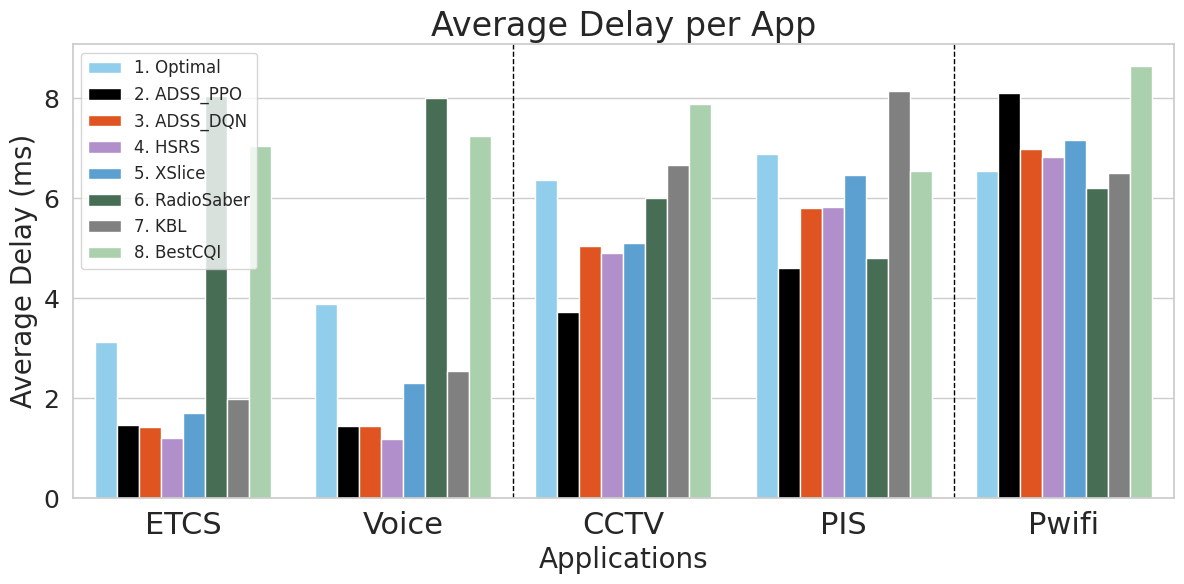

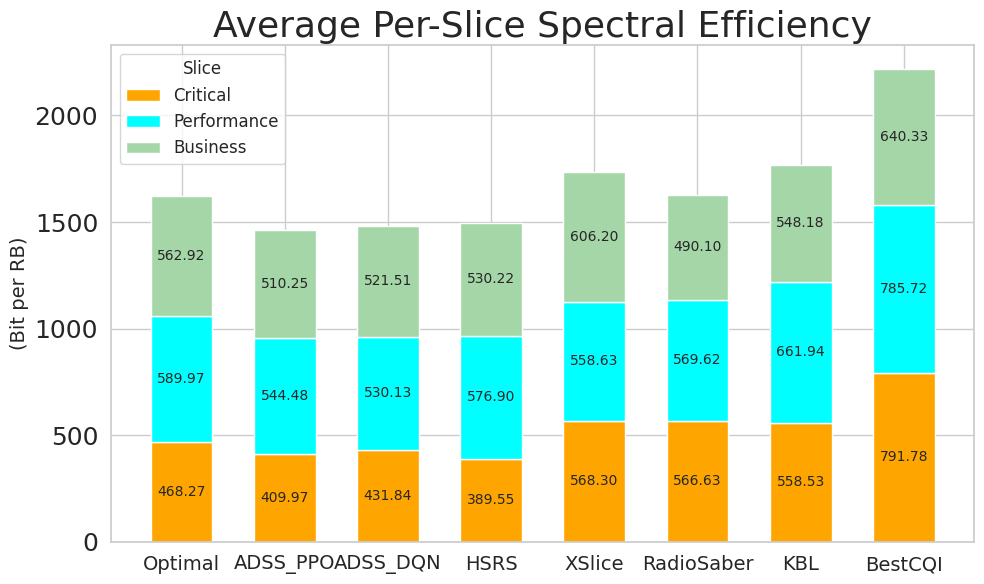

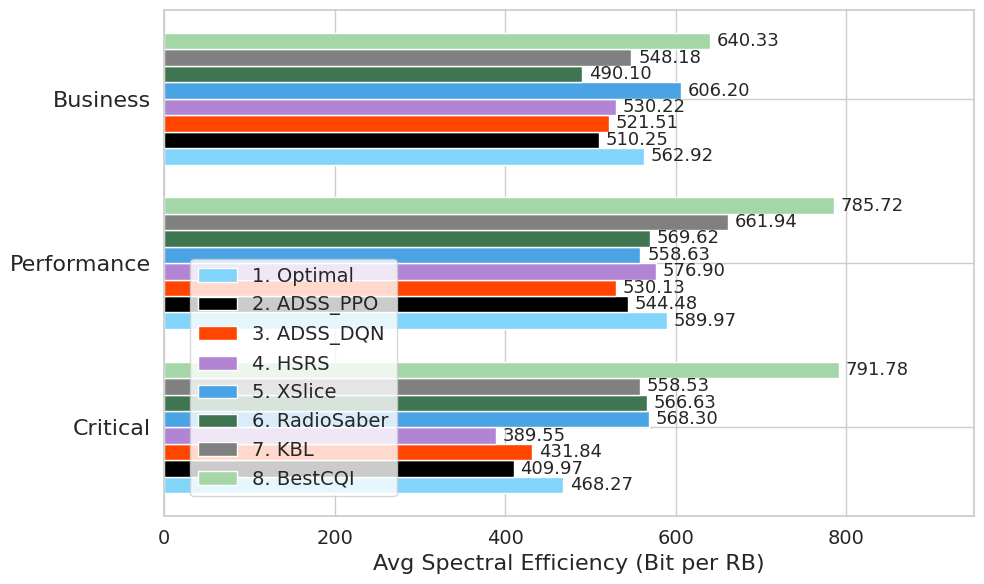


=== ADSS Delay and Throughput Violation Rates (%) ===
          Delay                Throughput               
         Critic  Perf Business     Critic  Perf Business
Method                                                  
ADSS_DQN   2.83  3.55    25.08       2.72  5.77    39.17
ADSS_PPO   3.86  5.83    23.53       3.86  9.97    36.67


In [4]:
import random
import numpy as np
import pandas as pd
import time 
from gurobipy import Model, GRB, quicksum
import math
from stable_baselines3.common.noise import NormalActionNoise
import matplotlib.pyplot as plt
import seaborn as sns

from typing import Optional
import gym
from gym import spaces
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

import os
from functools import lru_cache
from collections import defaultdict

%load_ext autoreload
%autoreload 2

from ourfunctions import (
    generate_gamma,
    run_myheuristic_allocation,
    run_allocation_solver,
    run_bestcqi_allocation,
    run_radiosaber_allocation,
    run_kbl_allocation,
    run_xslice_allocation,
    plot_all_results, print_final_results,
    get_sla, get_num_users_for_slice, get_slice_for_app,
    slice_spectral_efficiency, prbs_used_per_slice,plot_training_metrics, plot_all_results, plot_compare_training,
    compute_delay_violation_metrics, APP_PACKET_PROFILE,
    APPKEY_LIST,
    K, T,
    min_required_datarate_KB
)
num_simulations = 300
TRAIN_XSLICE = True
TRAIN_DQN = False
TRAIN_PPO = False
# Algorithm enablers (default: all enabled)
ENABLE_OPTIMAL_ILP = True
ENABLE_ADSS_DQN = True
ENABLE_ADSS_PPO = True
ENABLE_HSRS = True
ENABLE_XSLICE = True
ENABLE_RADIOSABER = True
ENABLE_KBL = True
ENABLE_BESTCQI = True

DQN_CKPT_PATH = "dqn_q_net.pth"
PPO_CKPT_PATH = "ppo_adss_checkpoint.pth"

hidden_size=128
n_steps=250
agent_gamma = 0.99
lam=0.25
clip_range=0.2
lr=0.005
batch_size=64
n_epochs=8
alpha=0.8
lambda_weight=0.5
# Slice priority weights (edit these three values if needed)
W_CRIT = 0.55
W_PERF = 0.3
W_BUSI = 0.15
WS = {1: W_CRIT, 2: W_PERF, 3: W_BUSI}
# Backward-compatible alias
weights = WS
entropy_coef=0.02 
value_coef = 0.5
partial_train_steps= K * T
train_episode= 150
violation_threshold = 2
usage_threshold = 95
train_stop_reward = 30
train_stop_viol = 1
train_prb_usage = 100
FEEDBACK_DELAY = 0
ERASURE_PROB = 0
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

ACTION_NONE, ACTION_CRITIC, ACTION_PERF, ACTION_BUSI = 0, 1, 2, 3
N_ACTIONS = 4
OBS_DIM = 8
# Reward shaping (paper-style delta +/- with lightweight critical delay penalty)
DELTA_POS_RHO = 0.7
DELAY_ETA_NEW = 1.0
DELAY_ETA_BACKLOG = 0.5
REWARD_SCALE = 20.0
frames = []

def get_algo_enablers():
    return {
        "Optimal_ILP": ENABLE_OPTIMAL_ILP,
        "ADSS_DQN": ENABLE_ADSS_DQN,
        "ADSS_PPO": ENABLE_ADSS_PPO,
        "HSRS": ENABLE_HSRS,
        "XSlice": ENABLE_XSLICE,
        "RadioSaber": ENABLE_RADIOSABER,
        "KBL": ENABLE_KBL,
        "BestCQI": ENABLE_BESTCQI,
    }
def safe_torch_load(path, map_location=None):
    try:
        if map_location is None:
            return torch.load(path, weights_only=True)
        return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        if map_location is None:
            return torch.load(path)
        return torch.load(path, map_location=map_location)


#print(f"the minimum required {min_required_datarate_KB}")


class MultiSliceAllocationEnv(gym.Env):
    def __init__(self, input_gamma=None, decision_gamma=None, actual_gamma=None):
        super().__init__()
        self.input_gamma = input_gamma
        self.decision_gamma_input = decision_gamma
        self.actual_gamma_input = actual_gamma
        self.action_space = gym.spaces.Discrete(N_ACTIONS)
        self.observation_space = gym.spaces.Box(
            low=0.0, high=1e9, shape=(OBS_DIM,), dtype=np.float32
        )
        self.T = T
        self.K = K
        self.current_t = 0
        self.current_prb = 0
        self.slot_winners = set()
        self.gamma_critic = 0.0
        self.gamma_perf   = 0.0
        self.gamma_busi   = 0.0
        self.best_critic_delta   = 0.0
        self.gamma = {}
        self.actual_gamma = {}
        self.decision_gamma = {}
        self.decision_gamma_by_prb = defaultdict(list)
        self.allocation_so_far = {ak:0.0 for ak in APPKEY_LIST}
        self.mask_appkey = {ak:1 for ak in APPKEY_LIST}
        self.allocation_records = []
        self.best_critic_appkey = None
        self.best_perf_appkey   = None
        self.best_busi_appkey   = None
        self.best_critic_delta_appkey   = None
        self.critical_appkeys = [ak for ak in APPKEY_LIST if ak[2] == 1]
        self.crit_deadline_slot = {}
        self.delay_violation_marked = {}
        wsum = float(sum(WS.values()))
        self.slice_reward_weight = {
            s: (float(WS.get(s, 1.0)) / wsum) if wsum > 0 else (1.0 / 3.0)
            for s in [1, 2, 3]
        }
        self.reset()

    def _init_delay_tracking(self):
        # Critical app deadline in slots (slot=1ms): ceil(pdb_ms/1), clamped in [1,T].
        self.crit_deadline_slot = {}
        for _, app_id, _ in self.critical_appkeys:
            if app_id in self.crit_deadline_slot:
                continue
            cfg = APP_PACKET_PROFILE.get(app_id, {})
            pdb_ms = float(cfg.get("pdb_ms", self.T))
            if not np.isfinite(pdb_ms) or pdb_ms <= 0:
                pdb_ms = float(self.T)
            dslot = int(math.ceil(pdb_ms / 1.0))
            self.crit_deadline_slot[app_id] = max(1, min(self.T, dslot))
        # Once a critical app misses its deadline, violation is irreversible in this episode.
        self.delay_violation_marked = {ak: False for ak in self.critical_appkeys}

    def _ratio_score(self, delta: float):
        """
        Paper-style delta reward:
          delta>=1 -> positive diminishing return
          delta<1  -> linear negative shortfall
        """
        if delta >= 1.0:
            return 1.0 / max(delta ** DELTA_POS_RHO, 1e-9)
        return -(1.0 - delta)

    def _weighted_delta_score(self):
        slice_sum = {1: 0.0, 2: 0.0, 3: 0.0}
        slice_cnt = {1: 0, 2: 0, 3: 0}

        for appk in APPKEY_LIST:
            app_id = appk[1]
            s = appk[2]
            sla = float(get_sla(app_id))
            if sla <= 0:
                continue
            alloc = float(self.allocation_so_far.get(appk, 0.0))
            delta = alloc / max(sla, 1e-9)
            slice_sum[s] += self._ratio_score(delta)
            slice_cnt[s] += 1

        weighted = 0.0
        for s in [1, 2, 3]:
            avg = (slice_sum[s] / slice_cnt[s]) if slice_cnt[s] > 0 else 0.0
            weighted += self.slice_reward_weight[s] * avg
        return weighted

    def _slice_unmet_ratios(self):
        """
        Per-slice unmet ratio in [0,1]:
          unmet_ratio[s] = sum(max(0, SLA-alloc)) / sum(SLA)
        """
        demand = {1: 0.0, 2: 0.0, 3: 0.0}
        unmet = {1: 0.0, 2: 0.0, 3: 0.0}

        for appk in APPKEY_LIST:
            app_id = appk[1]
            s = appk[2]
            sla = float(get_sla(app_id))
            if sla <= 0:
                continue
            alloc = float(self.allocation_so_far.get(appk, 0.0))
            demand[s] += sla
            unmet[s] += max(0.0, sla - alloc)

        ratios = {}
        for s in [1, 2, 3]:
            ratios[s] = (unmet[s] / demand[s]) if demand[s] > 0 else 0.0
        return ratios

    def _critical_delay_penalty_rates(self, slot_ref: int):
        """
        Returns (new_violation_rate, overdue_backlog_rate) for critical apps
        at the current slot reference.
        """
        if slot_ref < 0 or not self.critical_appkeys:
            return 0.0, 0.0

        num_crit = len(self.critical_appkeys)
        new_viol = 0
        overdue_backlog_sum = 0.0

        for appk in self.critical_appkeys:
            app_id = appk[1]
            sla = float(get_sla(app_id))
            if sla <= 0:
                continue

            deadline = self.crit_deadline_slot.get(app_id, self.T)
            if (slot_ref + 1) < deadline:
                continue

            alloc = float(self.allocation_so_far.get(appk, 0.0))
            if (not self.delay_violation_marked.get(appk, False)) and alloc < sla:
                self.delay_violation_marked[appk] = True
                new_viol += 1

            if alloc < sla:
                overdue_backlog_sum += (sla - alloc) / max(sla, 1e-9)

        return new_viol / max(num_crit, 1), overdue_backlog_sum / max(num_crit, 1)

    def _global_reward_score(self, slot_ref: int):
        thr_score = self._weighted_delta_score()
        new_viol_rate, overdue_backlog_rate = self._critical_delay_penalty_rates(slot_ref)
        delay_pen = self.slice_reward_weight[1] * (
            DELAY_ETA_NEW * new_viol_rate + DELAY_ETA_BACKLOG * overdue_backlog_rate
        )
        return thr_score - delay_pen

    def _build_prb_index(self, gamma_map):
        prb_map = defaultdict(list)
        for (u, a, s, p), thr in gamma_map.items():
            prb_map[p].append(((u, a, s), thr))
        return prb_map

    def _first_eligible_appkey(self, slice_id, slack=None):
        for appk in APPKEY_LIST:
            if appk[2] != slice_id:
                continue
            if self.mask_appkey.get(appk, 0) == 0:
                continue
            if slack is not None:
                if slack.get(appk, 0.0) <= 0.0:
                    continue
            else:
                sla = float(get_sla(appk[1]))
                alloc = float(self.allocation_so_far[appk])
                if sla > 0 and alloc >= sla:
                    continue
            return appk
        return None

    def set_episode_gammas(self, actual_gamma, decision_gamma=None):
        self.input_gamma = actual_gamma
        self.actual_gamma_input = actual_gamma
        self.decision_gamma_input = actual_gamma if decision_gamma is None else decision_gamma

    def reset(self):
        self.current_t = 0
        self.current_prb = 0
        actual_gamma = (
            self.actual_gamma_input
            if self.actual_gamma_input is not None else
            self.input_gamma
            if self.input_gamma is not None else
            generate_gamma()
        )
        decision_gamma = (
            self.decision_gamma_input
            if self.decision_gamma_input is not None else
            actual_gamma
        )
        self.actual_gamma = actual_gamma
        self.decision_gamma = decision_gamma
        self.gamma = actual_gamma
        self.decision_gamma_by_prb = self._build_prb_index(self.decision_gamma)

        for ak in APPKEY_LIST:
            self.allocation_so_far[ak] = 0.0
            self.mask_appkey[ak] = 1
        self._init_delay_tracking()
        self.prev_global_score = self._global_reward_score(slot_ref=0)
        self.allocation_records.clear()
        return self._get_observation()
    def step(self, action):
        prb_idx = self.current_prb
        action = int(action)
        had_schedulable_choice = (
            self.best_critic_appkey is not None
            or self.best_perf_appkey is not None
            or self.best_busi_appkey is not None
        )

        # 1) pick the pre-computed best app for this PRB & slice
        choice_app = [
            None,
            self.best_critic_appkey,
            self.best_perf_appkey,
            self.best_busi_appkey
        ][action]

        # 3) allocate throughput for only the selected app
        if choice_app is not None:
            thr = self.actual_gamma.get((choice_app[0], choice_app[1], choice_app[2], prb_idx), 0.0)
            self.allocation_so_far[choice_app] += thr
            self.allocation_records.append(
                (self.current_t, prb_idx,
                choice_app[0], choice_app[1], choice_app[2],
                thr)
            )
           
            # 4) compute reward just for that single app
            
            sla = get_sla(choice_app[1])
            alloc = self.allocation_so_far[choice_app]
            if sla > 0:
                ratio = alloc / sla
                if ratio >= 1.0:
                    # mark SLA met
                    self.mask_appkey[choice_app] = 0

        # 5) advance PRB / slot pointers
        self.current_prb += 1
        if self.current_prb >= self.K:
            self.current_prb = 0
            self.current_t  += 1

        # Global reward is the incremental change of paper-style score.
        slot_ref = min(self.current_t, self.T - 1)
        curr_score = self._global_reward_score(slot_ref)
        reward = REWARD_SCALE * (curr_score - self.prev_global_score)
        self.prev_global_score = curr_score

        # Penalize idling when traffic is still unmet and this PRB had a schedulable choice.
        # Penalty magnitude is derived from slice weights and unmet ratios (no extra tuning term).
        if action == ACTION_NONE and had_schedulable_choice:
            unmet_ratios = self._slice_unmet_ratios()
            none_penalty_score = sum(
                self.slice_reward_weight[s] * unmet_ratios[s] for s in [1, 2, 3]
            )
            reward -= REWARD_SCALE * none_penalty_score

        done = (self.current_t >= self.T)
        obs  = self._get_observation()
        return obs, reward, done, {}

    def step_inference(self, action):
        """
        Inference-only step used for runtime latency measurement.
        It updates allocation/state exactly like `step`, but skips reward computation.
        Returns (obs, done).
        """
        prb_idx = self.current_prb
        action = int(action)
        choice_app = [
            None,
            self.best_critic_appkey,
            self.best_perf_appkey,
            self.best_busi_appkey
        ][action]

        if choice_app is not None:
            thr = self.actual_gamma.get((choice_app[0], choice_app[1], choice_app[2], prb_idx), 0.0)
            self.allocation_so_far[choice_app] += thr
            self.allocation_records.append(
                (self.current_t, prb_idx,
                 choice_app[0], choice_app[1], choice_app[2],
                 thr)
            )
            sla = get_sla(choice_app[1])
            alloc = self.allocation_so_far[choice_app]
            if sla > 0 and (alloc / sla) >= 1.0:
                self.mask_appkey[choice_app] = 0

        self.current_prb += 1
        if self.current_prb >= self.K:
            self.current_prb = 0
            self.current_t += 1

        done = (self.current_t >= self.T)
        obs = self._get_observation()
        return obs, done

    def _update_best_slices(self):
        prb = self.current_prb
        entries = self.decision_gamma_by_prb.get(prb, [])

        slack = {
            appk: max(0.0, get_sla(appk[1]) - self.allocation_so_far[appk])
            for appk in APPKEY_LIST if appk[2] == 1
        }
        self.best_critic_delta = 0.0
        self.gamma_critic = self.gamma_perf = self.gamma_busi = 0.0
        self.best_critic_appkey = self.best_perf_appkey = self.best_busi_appkey = None

        if not self.decision_gamma:
            self.best_critic_appkey = self._first_eligible_appkey(1, slack=slack)
            self.best_perf_appkey = self._first_eligible_appkey(2)
            self.best_busi_appkey = self._first_eligible_appkey(3)
            return

        for appk, thr in entries:
            if self.mask_appkey.get(appk, 0) == 0:
                continue

            slice_id = appk[2]
            if slice_id == 1:
                need = slack.get(appk, 0.0)
                if need <= 0.0:
                    continue
                delta = min(need, thr)
                if delta > self.best_critic_delta:
                    self.best_critic_delta = delta
                    self.gamma_critic = thr
                    self.best_critic_appkey = appk

            elif slice_id == 2:
                if thr > self.gamma_perf:
                    self.gamma_perf = thr
                    self.best_perf_appkey = appk

            else:
                if thr > self.gamma_busi:
                    self.gamma_busi = thr
                    self.best_busi_appkey = appk


    def _get_observation(self):
        self._update_best_slices()
        k = self.current_prb

        def filled_ratio(appk):
            if appk is None:
                return 1.0            # treat “no candidate” as fully fulfilled
            sla = get_sla(appk[1])
            alloc = self.allocation_so_far[appk]
            return min(alloc / sla, 1.0)

        fr_c = filled_ratio(self.best_critic_appkey)
        fr_p = filled_ratio(self.best_perf_appkey)
        fr_b = filled_ratio(self.best_busi_appkey)

        # compute γ_x as before (0 when appk is None)
        g_c = (self.gamma_critic / 1070.055) if self.best_critic_appkey else 0.0
        g_p = (self.gamma_perf   / 1070.055) if self.best_perf_appkey   else 0.0
        g_b = (self.gamma_busi   / 1070.055) if self.best_busi_appkey   else 0.0

        return np.array([
            float(self.current_t),
            float(k) / (self.K - 1),
            g_c, g_p, g_b,
            fr_c, fr_p, fr_b
        ], dtype=np.float32)


class RolloutBuffer:
    def __init__(self, buffer_size, obs_dim):
        self.buffer_size = buffer_size
        self.obs_dim = obs_dim
        self.observations = np.zeros((buffer_size, obs_dim), dtype=np.float32)
        # keep actions as a single int per step:
        self.actions      = np.zeros(buffer_size,         dtype=np.int32)
        self.rewards      = np.zeros(buffer_size,         dtype=np.float32)
        self.values       = np.zeros(buffer_size,         dtype=np.float32)
        self.dones        = np.zeros(buffer_size,         dtype=bool)
        self.logprobs     = np.zeros(buffer_size,         dtype=np.float32)
        self.advantages   = np.zeros(buffer_size,         dtype=np.float32)
        self.returns      = np.zeros(buffer_size,         dtype=np.float32)
        self.ptr = 0
        self.path_start_idx = 0

    def store(self, obs, action, reward, value, logprob, done):
        idx = self.ptr
        self.observations[idx] = obs
        self.actions[idx]      = action
        self.rewards[idx]      = reward
        self.values[idx]       = value
        self.logprobs[idx]     = logprob
        self.dones[idx]        = done
        self.ptr += 1

    def finish_path(self, last_value, gamma=0.99, lam=0.95):
        path_end = self.ptr
        adv = 0.0
        # compute GAE backwards
        for i in reversed(range(self.path_start_idx, path_end)):
            next_val = 0.0 if self.dones[i] else (
                last_value if i == path_end - 1 else self.values[i+1]
            )
            delta = self.rewards[i] + gamma * next_val - self.values[i]
            adv    = delta + gamma * lam * (0 if self.dones[i] else adv)
            self.advantages[i] = adv
        # compute returns
        for i in range(self.path_start_idx, path_end):
            self.returns[i] = self.values[i] + self.advantages[i]
        self.path_start_idx = self.ptr

    def get(self, batch_size, shuffle=True):
        idxs = np.arange(self.ptr)
        if shuffle:
            np.random.shuffle(idxs)
        for start in range(0, self.ptr, batch_size):
            end = start + batch_size
            batch = idxs[start:end]
            yield (
                self.observations[batch],
                self.actions[batch],      # now shape (batch_size,)
                self.advantages[batch],
                self.returns[batch],
                self.logprobs[batch]
            )

    def reset(self):
        self.ptr = 0
        self.path_start_idx = 0

class ActorNet(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden_size=128):
        super().__init__()
        self.policy = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_size, n_actions)
        )

    def forward(self, x):
        return self.policy(x)

class CriticNet(nn.Module):
    def __init__(self, obs_dim, hidden_size=128):
        super().__init__()
        self.value = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        return self.value(x).squeeze(-1)

# =====================================
#  PPO
# =====================================
class PPOAgent:
    def __init__(
        self,
        env,
        obs_dim,
        n_actions,
        lr=3e-4,
        gamma=0.99,
        lam=0.95,
        clip_eps=0.2,
        epochs=4,
        batch_size=64,
        hidden_size=128,
        entropy_coef=0.02,
        value_coef=0.5,
    ):
        self.env = env
        self.gamma = gamma
        self.lam   = lam
        self.clip_eps     = clip_eps
        self.ppo_epochs   = epochs
        self.batch_size   = batch_size
        self.entropy_coef = entropy_coef
        self.value_coef   = value_coef

        # separate networks
        self.actor = ActorNet(obs_dim, n_actions, hidden_size)
        self.critic = CriticNet(obs_dim, hidden_size)
        self.optimizer = optim.Adam(
            list(self.actor.parameters()) + list(self.critic.parameters()), lr=lr
        )

    def select_action(self, obs_np):
        obs = torch.from_numpy(obs_np).float().unsqueeze(0)
        logits = self.actor(obs)
        dist = Categorical(logits=logits)
        action = dist.sample()
        return (
            action.item(),
            dist.log_prob(action).item(),
            self.critic(obs).item()
        )

    def select_action_deterministic(self, obs_np):
        obs = torch.from_numpy(obs_np).float().unsqueeze(0)
        with torch.no_grad():
            logits = self.actor(obs)
            return int(torch.argmax(logits, dim=-1).item())

    def update(self, buffer):
        for _ in range(self.ppo_epochs):
            for (obs_b, act_b, adv_b, ret_b, logp_b) in buffer.get(self.batch_size):
                obs_t = torch.from_numpy(obs_b)
                act_t = torch.from_numpy(act_b)
                adv_t = torch.from_numpy(adv_b)
                ret_t = torch.from_numpy(ret_b)
                old_logp_t = torch.from_numpy(logp_b)
                adv_t = (adv_t - adv_t.mean()) / (adv_t.std() + 1e-8)

                # actor forward
                logits = self.actor(obs_t)
                dist = Categorical(logits=logits)
                logp = dist.log_prob(act_t)
                entropy = dist.entropy().mean()

                # critic forward
                value = self.critic(obs_t)

                # surrogate policy loss
                ratio = torch.exp(logp - old_logp_t)
                clipped = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * adv_t
                policy_loss = -torch.min(ratio * adv_t, clipped).mean()

                # value loss
                value_loss = nn.functional.mse_loss(value, ret_t)

                # total loss
                loss = policy_loss + self.value_coef * value_loss - self.entropy_coef * entropy

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
        buffer.reset()


def train_adss_ppo_agent(gamma, num_episodes, partial_train_steps, violation_threshold, usage_threshold):
    env = MultiSliceAllocationEnv(input_gamma=gamma)
    obs_dim   = env.observation_space.shape[0]
    n_actions = env.action_space.n

    agent = PPOAgent(
        env=env,
        obs_dim=obs_dim,
        n_actions=n_actions,
        lr=lr,
        gamma=agent_gamma,
        lam=lam,
        clip_eps=clip_range,
        epochs=4,
        batch_size=64,
        hidden_size=128,
        entropy_coef=entropy_coef,
        value_coef=value_coef,
    )
    buffer = RolloutBuffer(partial_train_steps, obs_dim)

    episodes, throughputs, prb_usages = [], [], []
    violations, rewards = [], []
    avg_gap_ratios, avg_prb_usages = [], []

    for ep in range(num_episodes):
        # Refresh channel realization each training episode to avoid overfitting collapse.
        ep_gamma = generate_gamma(time_idx=ep)
        env.set_episode_gammas(ep_gamma)
        obs = env.reset()
        ep_reward = 0.0
        for t in range(partial_train_steps):
            action, logp, value = agent.select_action(obs)
            next_obs, rew, done, _ = env.step(action)
            buffer.store(obs, action, rew, value, logp, done)
            obs = next_obs

            if done:
                last_val = 0.0
                obs = env.reset()
            else:
                with torch.no_grad():
                    last_val = agent.critic(torch.from_numpy(obs).float().unsqueeze(0)).item()

            if done or t == partial_train_steps - 1:
                buffer.finish_path(last_val, gamma=agent.gamma, lam=agent.lam)

        agent.update(buffer)

        # Evaluation on unseen channel realization.
        test_gamma = generate_gamma(time_idx=ep + num_episodes)
        test_env   = MultiSliceAllocationEnv(input_gamma=test_gamma)
        obs_eval   = test_env.reset()
        done_eval  = False
        eval_reward = 0.0
        while not done_eval:
            action = agent.select_action_deterministic(obs_eval)
            obs_eval, rew_eval, done_eval, _ = test_env.step(action)
            eval_reward += rew_eval

        metrics, _ = compute_adss_allocation_metrics(test_env)
        total_thr  = metrics['Total_Throughput']
        prb_usage  = metrics['PRB_Usage(%)']
        total_viol = metrics['Total_Violations']

        gap_vals = list(metrics.get('Avg_Gap_Ratio_By_App', {}).values())
        prb_vals = list(metrics.get('Avg_PRB_Usage_By_App', {}).values())
        avg_gap_ratio = np.mean(gap_vals) if gap_vals else 0.0
        avg_prb_usage = np.mean(prb_vals) if prb_vals else 0.0

        episodes.append(ep+1)
        throughputs.append(total_thr)
        prb_usages.append(prb_usage)
        violations.append(total_viol)
        rewards.append(eval_reward)
        avg_gap_ratios.append(avg_gap_ratio)
        avg_prb_usages.append(avg_prb_usage)

        print(
            f"[PPO training Ep {ep+1}] => Thr={total_thr:.2f}KB, PRB_Usage={prb_usage:.1f}%, Viol={total_viol}, Reward={eval_reward:.2f}"
        )
        #eval_reward >= train_stop_reward 
        if  total_viol <= train_stop_viol and prb_usage == 100 : # and eval_reward >= train_stop_reward
            print(
                f"Stopping PPO early at episode {ep+1}: "
                f"Reward={eval_reward:.2f} >= {train_stop_reward}, Violation={total_viol} <= {train_stop_viol} and PRB_usage ={prb_usage}"
            )
            break

    training_results_df = pd.DataFrame({
        'Episode':             episodes,
        'Total_Throughput_KB': throughputs,
        'PRB_Usage_%':         prb_usages,
        'Total_Violations':    violations,
        'Episode_Reward':      rewards,
        'Avg_Gap_Ratio':       avg_gap_ratios,
        'Avg_PRB_Usage':       avg_prb_usages,
    })

    return agent, env, training_results_df

def train_until_threshold(
    gamma,
    num_episodes,
    partial_train_steps,
    violation_threshold=violation_threshold, usage_threshold=usage_threshold
):
    max_attempts = 50
    attempt = 0
    while attempt < max_attempts:
        attempt += 1
        print(f">>> Training attempt #{attempt}")
        agent, env, training_df = train_adss_ppo_agent(
            gamma=gamma,
            num_episodes=num_episodes,
            partial_train_steps=partial_train_steps,
            violation_threshold=violation_threshold, usage_threshold=usage_threshold
        )
        if len(training_df) < num_episodes:
            print(f" Threshold reached on attempt #{attempt}")
            return agent, env, training_df
        print(f" Threshold NOT reached (ran full {num_episodes} episodes). Retrying...")

    raise RuntimeError(f"Failed to reach threshold in {max_attempts} attempts")

def heuristic_select_action(env, obs, w_perf=0.6, w_busi=0.4):
    """
    Two-phase PRB allocator:
      1) Critical slice: pick ACTION_CRITIC if any unmet slack remains.
      2) Performance vs Business: ACTION_PERF or ACTION_BUSI by weighted throughput.
      3) ACTION_NONE otherwise.
    """
    # Ensure best_*_appkey are up‐to‐date for the current PRB
    env._update_best_slices()
    k = env.current_prb

    # Helper: remaining slack = SLA – allocated
    def slack_for(appk):
        if appk is None:
            return 0.0
        sla   = get_sla(appk[1])
        alloc = env.allocation_so_far[appk]
        return max(0.0, sla - alloc)

    # Phase 1: critical
    crit_app = env.best_critic_appkey
    if crit_app is not None and slack_for(crit_app) > 0:
        return ACTION_CRITIC

    # Phase 2: perf vs busi
    best_score = 0.0
    best_act   = ACTION_NONE

    perf_app = env.best_perf_appkey
    if perf_app is not None and slack_for(perf_app) > 0:
        g = env.decision_gamma.get((*perf_app, k), 0.0)
        score = g * w_perf
        if score > best_score:
            best_score, best_act = score, ACTION_PERF

    busi_app = env.best_busi_appkey
    if busi_app is not None and slack_for(busi_app) > 0:
        g = env.decision_gamma.get((*busi_app, k), 0.0)
        score = g * w_busi
        if score > best_score:
            best_score, best_act = score, ACTION_BUSI

    if best_score > 0.0:
        return best_act

    # No positive candidate
    return ACTION_NONE


# ── Prefill function: run N episodes of the heuristic ──
def prefill_heuristic(agent, gamma, num_episodes=10):
    """
    Runs `num_episodes` of heuristic policy and stores each transition
    into agent's replay buffer before any learning begins.
    """
    demo_env = MultiSliceAllocationEnv(input_gamma=gamma)
    transitions = []
    for _ in range(num_episodes):
        obs = demo_env.reset()
        done = False
        while not done:
            act = heuristic_select_action(demo_env, obs)
            nxt, r, done, _ = demo_env.step(act)
            transitions.append((obs, act, r, nxt, done))
            obs = nxt

    # inject into the agent
    for obs, act, r, nxt, done in transitions:
        agent.store(obs, act, r, nxt, done)

# ------------------------
class TransformerDQNNet(nn.Module):
    def __init__(self, obs_dim, K, d_model=128, n_heads=4, n_layers=3):
        super().__init__()
        hidden=128
        self.mlp=nn.Sequential(
            nn.Linear(obs_dim,hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden,hidden),  nn.ReLU(inplace=True),
            nn.Linear(hidden,N_ACTIONS)
        )
    def forward(self,x):
        q=self.mlp(x)
        batch=x.size(0)
        valid = torch.ones(batch, N_ACTIONS, dtype=torch.bool, device=x.device)
        return q, valid
    
class DQNAgent:
    def __init__(self,
                 env,
                 K,
                 obs_dim,
                 # transformer args—accepted for backward compatibility but unused
                 d_model=None,
                 n_heads=None,
                 n_layers=None,
                 # replay & optimization
                 buffer_size=50_000,
                 batch_size=64,
                 lr=3e-4,
                 gamma=0.99,
                 tau=0.005,
                 # ε-greedy
                 eps_start=1.0,
                 eps_end=0.05,
                 eps_decay=10_000):
        # 1) store env + MDP params
        self.env = env
        self.K   = K
        self.obs_dim = obs_dim

        # 2) build Q-networks (simple MLP)
        self.q_net      = TransformerDQNNet(obs_dim, K)
        self.target_net = TransformerDQNNet(obs_dim, K)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        # 3) optimizer & hyperparameters
        self.optim = torch.optim.Adam(self.q_net.parameters(), lr=lr)
        self.gamma = gamma
        self.tau   = tau

        # ε-greedy schedule
        self.eps_start, self.eps_end, self.eps_decay = eps_start, eps_end, eps_decay
        self.total_steps = 0

        # 4) replay buffer
        self.batch_size  = batch_size
        self.mem_obs     = np.zeros((buffer_size, obs_dim), dtype=np.float32)
        self.mem_actions = np.zeros(buffer_size,      dtype=np.int64)
        self.mem_rewards = np.zeros(buffer_size,      dtype=np.float32)
        self.mem_next_obs= np.zeros((buffer_size, obs_dim), dtype=np.float32)
        self.mem_dones   = np.zeros(buffer_size,      dtype=bool)
        self.mem_ptr     = 0
        self.mem_filled  = 0

    def select_action(self, obs_np):
        # ε-greedy
        eps = self.eps_end + (self.eps_start - self.eps_end) * \
              math.exp(-1. * self.total_steps / self.eps_decay)
        self.total_steps += 1
        if np.random.rand() < eps:
            return np.random.randint(0, N_ACTIONS)

        with torch.no_grad():
            q, _ = self.q_net(torch.from_numpy(obs_np).float().unsqueeze(0))
            return int(q.argmax(dim=-1).item())

    def select_action_greedy(self, obs_np):
        with torch.no_grad():
            q, _ = self.q_net(torch.from_numpy(obs_np).float().unsqueeze(0))
            return int(q.argmax(dim=-1).item())

    def store(self, obs, action, reward, next_obs, done):
        idx = self.mem_ptr % len(self.mem_rewards)
        self.mem_obs[idx]      = obs
        self.mem_actions[idx]  = action
        self.mem_rewards[idx]  = reward
        self.mem_next_obs[idx] = next_obs
        self.mem_dones[idx]    = done
        self.mem_ptr    += 1
        self.mem_filled = min(self.mem_filled + 1, len(self.mem_rewards))

    def update_network(self):
        if self.mem_filled < self.batch_size:
            return
        idxs  = np.random.choice(self.mem_filled, self.batch_size, replace=False)
        obs_b = torch.from_numpy(self.mem_obs[idxs]).float()
        act_b = torch.from_numpy(self.mem_actions[idxs]).long().unsqueeze(-1)
        rew_b = torch.from_numpy(self.mem_rewards[idxs]).float()
        nxt_b = torch.from_numpy(self.mem_next_obs[idxs]).float()
        done_b= torch.from_numpy(self.mem_dones[idxs]).float()

        # Q(s,a)
        q_pred, _  = self.q_net(obs_b)
        q_sa       = q_pred.gather(-1, act_b).squeeze(-1)

        # target: r + γ max_a' Q_target(s',a')
        with torch.no_grad():
            q_next, _  = self.target_net(nxt_b)
            q_max_next = q_next.max(dim=-1).values
            target     = rew_b + self.gamma * (1 - done_b) * q_max_next

        loss = nn.functional.mse_loss(q_sa, target)
        self.optim.zero_grad()
        loss.backward()
        self.optim.step()

    def soft_update_target(self):
        with torch.no_grad():
            for p, pt in zip(self.q_net.parameters(), self.target_net.parameters()):
                pt.data.mul_(1 - self.tau).add_(p.data, alpha=self.tau)

    def learn(self,
              num_steps,
              start_learn=1000,
              update_every=4,
              behavior_fn=None):
        """
        Play `num_steps` PRB‐decisions, store each transition via `store()`,
        and call `update_network()` + `soft_update_target()` every `update_every`
        steps once we've stored at least max(start_learn, batch_size) samples.
        If `behavior_fn` is provided, use it(env, obs)->action; else ε-greedy.
        """
        if behavior_fn is None:
            behavior_fn = lambda e, o: self.select_action(o)

        obs = self.env.reset()
        for step in range(num_steps):
            act = behavior_fn(self.env, obs)
            nxt, r, done, _ = self.env.step(act)
            self.store(obs, act, r, nxt, done)
            obs = nxt if not done else self.env.reset()

            if (self.mem_filled >= start_learn
                    and self.mem_filled >= self.batch_size
                    and step % update_every == 0):
                self.update_network()
                self.soft_update_target()


def train_adss_dqn_agent(gamma,
                     num_episodes,
                     partial_train_steps,
                     w_perf=0.7,
                     w_busi=0.3):
    """
    gamma               : initial γ for episode 0
    num_episodes        : number of episodes to train over
    partial_train_steps : T*K steps per episode (e.g. 250)
    w_perf, w_busi      : weights for perf/busi in heuristic
    """
    # 1) init agent with dummy env
    env   = MultiSliceAllocationEnv(input_gamma=gamma)
    obs_dim = env.observation_space.shape[0]
    agent = DQNAgent(
        env=env,
        K=K,
        obs_dim=obs_dim,
        buffer_size=50_000,
        batch_size=batch_size,
        gamma=agent_gamma,
        lr=lr,
        tau=0.005,
        eps_start=1.0,
        eps_end=0.05,
        eps_decay=10_000,
    )

    def _checkpoint_rank(metric_dict):
        return (
            -int(metric_dict['Total_Violations']),
            float(metric_dict['PRB_Usage(%)']),
            float(metric_dict['Total_Throughput']),
        )

    # 2) main training loop
    metrics = []
    best_q_state = None
    best_metrics = None
    best_rank = None
    for ep in range(num_episodes):
        # a) new gamma & reset
        new_gamma = generate_gamma(time_idx=ep)
        agent.env.set_episode_gammas(new_gamma)
        agent.env.reset()

        # b) learn on-policy with epsilon-greedy exploration
        agent.learn(
            num_steps=partial_train_steps,
            start_learn=1000,
            update_every=4
        )

        # c) evaluate on fresh test env
        test_gamma = generate_gamma(time_idx=ep + num_episodes)
        test_env = MultiSliceAllocationEnv(input_gamma=test_gamma)
        obs = test_env.reset()
        done = False
        total_reward = 0.0
        while not done:
            a = agent.select_action_greedy(obs)
            obs, r, done, _ = test_env.step(a)
            total_reward += r

        m, _ = compute_adss_allocation_metrics(test_env)
        current_rank = _checkpoint_rank(m)
        if best_rank is None or current_rank > best_rank:
            best_rank = current_rank
            best_metrics = {
                'Episode': ep + 1,
                'Total_Throughput': float(m['Total_Throughput']),
                'PRB_Usage(%)': float(m['PRB_Usage(%)']),
                'Total_Violations': int(m['Total_Violations']),
                'Episode_Reward': float(total_reward),
            }
            best_q_state = {
                k: v.detach().cpu().clone()
                for k, v in agent.q_net.state_dict().items()
            }
            print(
                f"[DQN best checkpoint] Ep {ep+1:2d} | "
                f"Viol={m['Total_Violations']}, PRB={m['PRB_Usage(%)']:.1f}%, "
                f"Thr={m['Total_Throughput']:.1f}"
            )

        metrics.append({
            'Episode':              ep + 1,
            'Total_Throughput_KB':  m['Total_Throughput'],  # renamed for plotting
            'PRB_Usage_%':          m['PRB_Usage(%)'],     # renamed for plotting
            'Total_Violations':     m['Total_Violations'],
            'Episode_Reward':       total_reward
        })
        print(f"[DQN training Ep {ep+1:2d}] Thr={m['Total_Throughput']:.1f}, "
              f"PRB={m['PRB_Usage(%)']:.1f}%, Viol={m['Total_Violations']}, "
              f"Reward={total_reward:.2f}")
    if best_q_state is not None:
        agent.q_net.load_state_dict(best_q_state)
        agent.target_net.load_state_dict(best_q_state)
        print(
            f"[DQN best selected] Ep {best_metrics['Episode']:2d} | "
            f"Viol={best_metrics['Total_Violations']}, "
            f"PRB={best_metrics['PRB_Usage(%)']:.1f}%, "
            f"Thr={best_metrics['Total_Throughput']:.1f}"
        )

    df = pd.DataFrame(metrics)
    return agent, env, df

def compute_adss_allocation_metrics(env):
    columns = ['Slot','PRB','User','App','Slice','Throughput']
    alloc_df = pd.DataFrame(env.allocation_records, columns=columns)
    slice_throughput_df = (
        alloc_df
          .groupby('Slice')['Throughput']
          .sum()
          .reset_index()
          .rename(columns={'Throughput': 'Total_Throughput'})
    )  
    #alloc_df.to_csv("allocation_df_adss_metrics.csv", index= True)
    total_thr = alloc_df['Throughput'].sum()
    avg_thr   = total_thr 
    total_prbs = K * T
    used_prbs  = len(alloc_df)  
    prb_usage_percent = (used_prbs / total_prbs) * 100 if total_prbs > 0 else 0

    # Summarize throughput per (User, App, Slice)
    app_thr_df = (
        alloc_df
        .groupby(['User','App','Slice'])['Throughput']
        .sum()
        .reset_index()
    )

    # -------------
    # 1) Violation & Gap Calculation 
    # -------------
    violation_counts_per_slice = {1: 0, 2: 0, 3: 0}
    violation_gap_per_slice    = {1: 0.0, 2: 0.0, 3: 0.0}
    for (i_, a_, s_) in APPKEY_LIST:
        # Grab how much throughput was allocated to this (user, app, slice)
        row_match = app_thr_df[
            (app_thr_df['User'] == i_) &
            (app_thr_df['App'] == a_) &
            (app_thr_df['Slice'] == s_)
        ]
        sla_needed = get_sla(a_)
        if len(row_match) > 0:
            allocated_thr = row_match.iloc[0]['Throughput']
            ratio = allocated_thr / sla_needed
            if ratio < 1 :
                #gap_ratio = 1-ratio 
                violation_counts_per_slice[s_] += 1
                violation_gap_per_slice[s_] += (1.0 - ratio)
            

        else:
            allocated_thr = 0.0
            
            violation_counts_per_slice[s_] += 1
            violation_gap_per_slice[s_] += 1.0


    # Final step: turn total gap into an average gap for each slice
    for s_ in [1, 2, 3]:
        if violation_counts_per_slice[s_] > 0:
            violation_gap_per_slice[s_] /= violation_counts_per_slice[s_]
        else:
            violation_gap_per_slice[s_] = 0.0

    total_violations = sum(violation_counts_per_slice.values())

    # gap ratio per App
    gap_ratios = {}
    for (i_, a_, s_) in APPKEY_LIST:
        mask = (
            (app_thr_df['User']  == i_) &
            (app_thr_df['App']   == a_) &
            (app_thr_df['Slice'] == s_)
        )
        allocated = app_thr_df.loc[mask, 'Throughput'].sum()
        sla_needed = get_sla(a_)
        ratio = ((sla_needed - allocated) / sla_needed) if sla_needed > 0 else 0.0
        ratio = max(0.0, ratio)
        gap_ratios.setdefault(a_, []).append(ratio)
    avg_gap_ratio_by_app = {app: np.mean(ratios) for app, ratios in gap_ratios.items()}

    # Average number of PRBs used per app
    prb_counts = alloc_df.groupby('App').size().to_dict()  # {app -> #rows}
    avg_prb_usage_by_app = {}
    for app_id, count in prb_counts.items():
        slice_id = get_slice_for_app(app_id)
        n_users = get_num_users_for_slice(slice_id)
        avg_prb_usage_by_app[app_id] = count / float(n_users) if n_users > 0 else 0

    # -------------
    # 3) Final Return
    # -------------
    return {
        'allocation_df': alloc_df,
        'Total_Throughput':       total_thr, 
        'Average_Throughput':     avg_thr,
        'PRB_Usage(%)':           prb_usage_percent,
        'Violation_Counts_Per_Slice': violation_counts_per_slice,
        'Violation_Gap_Per_Slice':    violation_gap_per_slice,
        'Total_Violations':       total_violations,
        'App_Throughput_DF':      app_thr_df,
        'Avg_Gap_Ratio_By_App':   avg_gap_ratio_by_app,
        'Avg_PRB_Usage_By_App':   avg_prb_usage_by_app,
        'Slice_Throughput_df': slice_throughput_df,
    }, app_thr_df


def _build_uniform_gamma(actual_gamma, value=1.0):
    return {key: float(value) for key in actual_gamma}


def _first_unmet_appkey(allocation_so_far, slice_ids=None):
    allowed = None if slice_ids is None else set(slice_ids)
    for appk in APPKEY_LIST:
        if allowed is not None and appk[2] not in allowed:
            continue
        if allocation_so_far[appk] < float(get_sla(appk[1])):
            return appk
    return None


def _bestcqi_no_feedback_alloc_df(actual_gamma):
    columns = ['Slot', 'PRB', 'User', 'App', 'Slice', 'Throughput']
    if not actual_gamma:
        return pd.DataFrame(columns=columns)

    allocation_so_far = {ak: 0.0 for ak in APPKEY_LIST}
    records = []

    for t in range(T):
        for prb in range(K):
            chosen = _first_unmet_appkey(allocation_so_far)
            if chosen is None:
                continue
            thr = actual_gamma.get((chosen[0], chosen[1], chosen[2], prb), 0.0)
            allocation_so_far[chosen] += thr
            records.append((t, prb, chosen[0], chosen[1], chosen[2], thr))

    return pd.DataFrame(records, columns=columns)


def _hsrs_no_feedback_alloc_df(actual_gamma):
    columns = ['Slot', 'PRB', 'User', 'App', 'Slice', 'Throughput']
    if not actual_gamma:
        return pd.DataFrame(columns=columns)

    allocation_so_far = {ak: 0.0 for ak in APPKEY_LIST}
    records = []

    for t in range(T):
        for prb in range(K):
            chosen = _first_unmet_appkey(allocation_so_far, slice_ids=[1])
            if chosen is None:
                chosen = _first_unmet_appkey(allocation_so_far, slice_ids=[2, 3])
            if chosen is None:
                continue
            thr = actual_gamma.get((chosen[0], chosen[1], chosen[2], prb), 0.0)
            allocation_so_far[chosen] += thr
            records.append((t, prb, chosen[0], chosen[1], chosen[2], thr))

    return pd.DataFrame(records, columns=columns)


def _radiosaber_no_feedback_alloc_df(actual_gamma):
    columns = ['Slot', 'PRB', 'User', 'App', 'Slice', 'Throughput']
    if not actual_gamma:
        return pd.DataFrame(columns=columns)

    RBG_size = 4
    num_RBG = math.ceil(K / RBG_size)
    slice_order = [1, 2, 3]
    payload_to_send = {key: float(get_sla(key[1])) for key in APPKEY_LIST}
    slice_payload = defaultdict(float)
    for (u, a, s), rem in payload_to_send.items():
        slice_payload[s] += rem

    records = []
    for t in range(T):
        total_rem = sum(slice_payload.values())
        if total_rem > 0:
            weights = {s: slice_payload[s] / total_rem for s in slice_order}
        else:
            weights = {s: 0.0 for s in slice_order}
        quotas = {s: int(round(weights[s] * num_RBG)) for s in slice_order}
        used = {s: 0 for s in slice_order}

        offset = t % RBG_size
        prb_seq = list(range(offset, K)) + list(range(0, offset))

        for r in range(num_RBG):
            prb_group = prb_seq[r * RBG_size : (r + 1) * RBG_size]
            sel_slice = None
            for s in slice_order:
                if used[s] < quotas[s] and slice_payload[s] > 0:
                    sel_slice = s
                    used[s] += 1
                    break
            if sel_slice is None:
                continue

            chosen = None
            for appk in APPKEY_LIST:
                if appk[2] != sel_slice:
                    continue
                if payload_to_send[appk] > 0:
                    chosen = appk
                    break
            if chosen is None:
                continue

            for prb in prb_group:
                thr = actual_gamma.get((chosen[0], chosen[1], chosen[2], prb), 0.0)
                if thr <= 0:
                    continue
                remaining = payload_to_send[chosen]
                if remaining <= 0:
                    break
                actual = min(thr, remaining)
                payload_to_send[chosen] -= actual
                slice_payload[sel_slice] -= actual
                records.append((t, prb, chosen[0], chosen[1], chosen[2], actual))

    return pd.DataFrame(records, columns=columns)


def _kbl_no_feedback_alloc_df(actual_gamma):
    uniform_gamma = _build_uniform_gamma(actual_gamma)
    alloc_df, *_ = run_kbl_allocation(uniform_gamma)
    return _apply_actual_gamma_to_alloc_df(alloc_df, actual_gamma)


def _xslice_no_feedback_alloc_df(actual_gamma, train_if_missing=True):
    uniform_gamma = _build_uniform_gamma(actual_gamma)
    alloc_df, *_ = run_xslice_allocation(uniform_gamma, train_if_missing=train_if_missing)
    return _apply_actual_gamma_to_alloc_df(alloc_df, actual_gamma)


def _apply_actual_gamma_to_alloc_df(alloc_df, actual_gamma):
    columns = ['Slot', 'PRB', 'User', 'App', 'Slice', 'Throughput']
    if alloc_df is None or alloc_df.empty:
        return pd.DataFrame(columns=columns)

    base_df = alloc_df[['Slot', 'PRB', 'User', 'App', 'Slice']].copy()
    records = []
    for row in base_df.itertuples(index=False):
        thr = actual_gamma.get((int(row.User), int(row.App), int(row.Slice), int(row.PRB)), 0.0)
        records.append((int(row.Slot), int(row.PRB), int(row.User), int(row.App), int(row.Slice), thr))
    return pd.DataFrame(records, columns=columns)


def _metrics_from_alloc_df(alloc_df):
    columns = ['Slot', 'PRB', 'User', 'App', 'Slice', 'Throughput']
    if alloc_df is None or alloc_df.empty:
        alloc_df = pd.DataFrame(columns=columns)
    else:
        alloc_df = alloc_df[columns].copy()

    total_prbs = K * T
    total_thr = float(alloc_df['Throughput'].sum()) if not alloc_df.empty else 0.0
    prb_usage_percent = (len(alloc_df) / total_prbs) * 100 if total_prbs > 0 else 0.0

    if alloc_df.empty:
        app_thr_df = pd.DataFrame(columns=['User', 'App', 'Slice', 'Throughput'])
        slice_throughput_df = pd.DataFrame(columns=['Slice', 'Total_Throughput'])
    else:
        app_thr_df = (
            alloc_df.groupby(['User', 'App', 'Slice'])['Throughput']
            .sum()
            .reset_index()
        )
        slice_throughput_df = (
            alloc_df.groupby('Slice')['Throughput']
            .sum()
            .reset_index()
            .rename(columns={'Throughput': 'Total_Throughput'})
        )

    all_combos_df = pd.DataFrame(APPKEY_LIST, columns=['User', 'App', 'Slice'])
    merged_df = all_combos_df.merge(app_thr_df, on=['User', 'App', 'Slice'], how='left')
    merged_df['Throughput'] = merged_df['Throughput'].fillna(0.0)

    app_episode_thr = (
        merged_df.groupby('App')['Throughput']
        .mean()
        .reset_index()
        .rename(columns={'Throughput': 'Average_Throughput'})
    )

    violation_counts_per_slice = {1: 0, 2: 0, 3: 0}
    violation_gap_per_slice = {1: 0.0, 2: 0.0, 3: 0.0}
    for (i_, a_, s_) in APPKEY_LIST:
        allocated_thr = merged_df.loc[
            (merged_df['User'] == i_) &
            (merged_df['App'] == a_) &
            (merged_df['Slice'] == s_),
            'Throughput'
        ].iloc[0]
        sla_needed = float(get_sla(a_))
        ratio = (allocated_thr / sla_needed) if sla_needed > 0 else 1.0
        if ratio < 1.0:
            violation_counts_per_slice[s_] += 1
            violation_gap_per_slice[s_] += (1.0 - ratio)

    for s_ in [1, 2, 3]:
        if violation_counts_per_slice[s_] > 0:
            violation_gap_per_slice[s_] /= violation_counts_per_slice[s_]

    total_violations = sum(violation_counts_per_slice.values())

    return (
        alloc_df,
        total_thr,
        app_thr_df,
        app_episode_thr,
        violation_counts_per_slice,
        total_violations,
        violation_gap_per_slice,
        slice_throughput_df,
    )


def run_method_with_feedback(method_fn, actual_gamma, decision_gamma, fallback_fn=None, *args, **kwargs):
    if not decision_gamma:
        if fallback_fn is None:
            alloc_df = pd.DataFrame(columns=['Slot', 'PRB', 'User', 'App', 'Slice', 'Throughput'])
        else:
            alloc_df = fallback_fn(actual_gamma, *args, **kwargs)
        return _metrics_from_alloc_df(alloc_df)

    result = method_fn(decision_gamma, *args, **kwargs)
    alloc_df = result[0] if result else None
    alloc_df = _apply_actual_gamma_to_alloc_df(alloc_df, actual_gamma)
    return _metrics_from_alloc_df(alloc_df)


def run_simulation(num_simulations=3, alpha=0.8, lambda_weight=0.7):
    enabled = get_algo_enablers()
    if not any(enabled.values()):
        raise ValueError("All algorithms are disabled. Enable at least one ENABLE_* flag.")

    total_prbs = K * T
    simulation_results = []
    training_results_dqn = None
    training_results_ppo = None

    def _app_thr_cols(prefix, app_episode_df):
        if app_episode_df is None or app_episode_df.empty:
            return {}
        return {
            f"{prefix}_App_{int(app)}_Throughput": avg_thr
            for app, avg_thr in app_episode_df[['App', 'Average_Throughput']].itertuples(index=False)
        }

    def _adss_episode_means(app_thr_df):
        all_combos_df = pd.DataFrame(APPKEY_LIST, columns=['User', 'App', 'Slice'])
        merged_df = all_combos_df.merge(
            app_thr_df,
            on=['User', 'App', 'Slice'],
            how='left'
        )
        merged_df['Throughput'] = merged_df['Throughput'].fillna(0.0)
        app_episode_df = (
            merged_df
            .groupby('App')['Throughput']
            .mean()
            .reset_index()
            .rename(columns={'Throughput': 'Average_Throughput'})
        )
        return app_episode_df, merged_df

    def _compute_jain_fairness_from_alloc_df(alloc_df):
        """
        User-level Jain fairness per episode:
          x_u = total throughput allocated to user u (summed across apps/slices).
          J = (sum x_u)^2 / (N * sum x_u^2)
        """
        user_ids = sorted({u for (u, _, _) in APPKEY_LIST})
        n_users = len(user_ids)
        if n_users == 0:
            return 0.0

        if alloc_df is None or alloc_df.empty:
            return 0.0

        per_user_thr = alloc_df.groupby('User')['Throughput'].sum().to_dict()
        vec = np.array([float(per_user_thr.get(u, 0.0)) for u in user_ids], dtype=np.float64)
        denom = float(n_users) * float(np.sum(vec * vec))
        if denom <= 1e-12:
            return 0.0
        num = float(np.sum(vec)) ** 2
        return float(num / denom)

    need_rl_train_gamma = (
        (enabled["ADSS_DQN"] and TRAIN_DQN) or
        (enabled["ADSS_PPO"] and TRAIN_PPO)
    )
    gamma_for_training = generate_gamma() if need_rl_train_gamma else None

    adss_dqn_agent = None
    if enabled["ADSS_DQN"]:
        if TRAIN_DQN:
            start_time_adss_training = time.time()
            adss_dqn_agent, _, training_results_dqn = train_adss_dqn_agent(
                gamma=gamma_for_training,
                num_episodes=train_episode,
                partial_train_steps=partial_train_steps
            )
            time_taken_adss_training = time.time() - start_time_adss_training
            print(f"[RL Training][DQN] Done. Time Taken={time_taken_adss_training:.2f}s")
            torch.save(adss_dqn_agent.q_net.state_dict(), DQN_CKPT_PATH)
            print(f"Trained DQN Q-network saved to {DQN_CKPT_PATH}")
        else:
            print(f"[RL Training][DQN] Skipped. Will load checkpoint: {DQN_CKPT_PATH}")

        dummy_env = MultiSliceAllocationEnv(input_gamma=generate_gamma())
        obs_dim = dummy_env.observation_space.shape[0]
        adss_dqn_agent = DQNAgent(
            env=dummy_env,
            K=K,
            obs_dim=obs_dim,
            d_model=hidden_size,
            n_heads=4,
            n_layers=3,
            buffer_size=50_000,
            batch_size=batch_size,
            lr=lr,
            gamma=agent_gamma,
            eps_start=1.0,
            eps_end=0.05,
            eps_decay=10_000,
        )
        if not os.path.isfile(DQN_CKPT_PATH):
            raise FileNotFoundError(
                f"DQN checkpoint not found at '{DQN_CKPT_PATH}'. "
                f"Set TRAIN_DQN=True once to train and save it."
            )
        adss_dqn_agent.q_net.load_state_dict(safe_torch_load(DQN_CKPT_PATH))
        adss_dqn_agent.q_net.eval()
        print("Loaded trained DQN network for inference!")
    else:
        print("[ADSS_DQN] Disabled by ENABLE_ADSS_DQN=False")

    adss_ppo_agent = None
    if enabled["ADSS_PPO"]:
        if TRAIN_PPO:
            start_time_adss_training = time.time()
            adss_ppo_agent, _, training_results_ppo = train_adss_ppo_agent(
                gamma=gamma_for_training,
                num_episodes=train_episode,
                partial_train_steps=partial_train_steps,
                violation_threshold=violation_threshold,
                usage_threshold=usage_threshold
            )
            time_taken_adss_training = time.time() - start_time_adss_training
            print(f"[RL Training][PPO] Done. Time Taken={time_taken_adss_training:.2f}s")
            torch.save({
                'actor': adss_ppo_agent.actor.state_dict(),
                'critic': adss_ppo_agent.critic.state_dict()
            }, PPO_CKPT_PATH)
            print(f"Trained PPO policy saved to {PPO_CKPT_PATH}")
        else:
            print(f"[RL Training][PPO] Skipped. Will load checkpoint: {PPO_CKPT_PATH}")

        dummy_env = MultiSliceAllocationEnv(input_gamma=generate_gamma())
        obs_dim = dummy_env.observation_space.shape[0]
        n_actions = dummy_env.action_space.n
        adss_ppo_agent = PPOAgent(
            env=dummy_env,
            obs_dim=obs_dim,
            n_actions=n_actions,
            lr=3e-3,
            gamma=0.98,
            lam=0.95,
            clip_eps=clip_range,
            epochs=4,
            batch_size=64,
            hidden_size=128,
            entropy_coef=entropy_coef,
            value_coef=value_coef,
        )
        if not os.path.isfile(PPO_CKPT_PATH):
            raise FileNotFoundError(
                f"PPO checkpoint not found at '{PPO_CKPT_PATH}'. "
                f"Set TRAIN_PPO=True once to train and save it."
            )
        ckpt = safe_torch_load(PPO_CKPT_PATH)
        adss_ppo_agent.actor.load_state_dict(ckpt['actor'])
        adss_ppo_agent.critic.load_state_dict(ckpt['critic'])
        adss_ppo_agent.actor.eval()
        adss_ppo_agent.critic.eval()
        print("Loaded trained PPO network for inference!")
    else:
        print("[ADSS_PPO] Disabled by ENABLE_ADSS_PPO=False")

    if training_results_dqn is not None and training_results_ppo is not None:
        plot_compare_training(training_results_dqn, training_results_ppo)

    feedback_delay = max(0, int(FEEDBACK_DELAY))
    erasure_prob = min(max(float(ERASURE_PROB), 0.0), 1.0)
    gamma_history = []
    latest_gamma = {}

    for sim in range(1, num_simulations + 1):
        gamma = generate_gamma(time_idx=sim + 1)
        feedback_erased = np.random.rand() < erasure_prob
        delayed_gamma = None
        if not feedback_erased:
            if feedback_delay == 0:
                delayed_gamma = gamma
            elif len(gamma_history) >= feedback_delay:
                delayed_gamma = gamma_history[-feedback_delay]

        if delayed_gamma is not None:
            decision_gamma = delayed_gamma
        elif latest_gamma:
            decision_gamma = latest_gamma
        else:
            decision_gamma = {}

        method_alloc_df = {}
        method_tot_thr = {}
        method_usage = {}
        method_time = {}
        method_viol_cnt = {}
        method_tot_viol = {}
        method_viol_gap = {}
        method_slice_cols = {}
        method_se_cols = {}
        method_app_cols = {}

        if enabled["HSRS"]:
            t0 = time.time()
            (alloc_df_my, total_thr_my, _,
             app_episode_thr_my, viol_cnt_my,
             tot_viol_my, viol_gap_my, slice_thr_df_my) = run_method_with_feedback(
                run_myheuristic_allocation, gamma, decision_gamma, _hsrs_no_feedback_alloc_df
            )
            method_alloc_df["HSRS"] = alloc_df_my
            method_tot_thr["HSRS"] = total_thr_my
            method_usage["HSRS"] = len(alloc_df_my) / total_prbs * 100
            method_time["HSRS"] = time.time() - t0
            method_viol_cnt["HSRS"] = viol_cnt_my
            method_tot_viol["HSRS"] = tot_viol_my
            method_viol_gap["HSRS"] = viol_gap_my
            slice_thr = slice_thr_df_my.set_index('Slice')['Total_Throughput'].to_dict()
            method_slice_cols["HSRS"] = {f"HSRS_S{s}_Throughput": slice_thr.get(s, 0.0) for s in [1, 2, 3]}
            method_se_cols["HSRS"] = {f"HSRS_SE_S{s}": slice_spectral_efficiency(alloc_df_my).get(s, 0) for s in [1, 2, 3]}
            method_app_cols["HSRS"] = _app_thr_cols("HSRS", app_episode_thr_my)

        if enabled["Optimal_ILP"]:
            t0 = time.time()
            (alloc_df_opt, total_thr_opt, _,
             app_episode_thr_opt, viol_cnt_opt,
             tot_viol_opt, viol_gap_opt, slice_thr_df_opt) = run_allocation_solver(gamma, alpha, lambda_weight)
            if alloc_df_opt is None:
                alloc_df_opt = pd.DataFrame(columns=['Slot', 'PRB', 'User', 'App', 'Slice', 'Throughput'])
                total_thr_opt = 0.0
                app_episode_thr_opt = pd.DataFrame(columns=['App', 'Average_Throughput'])
                viol_cnt_opt = {1: 0, 2: 0, 3: 0}
                tot_viol_opt = 0
                viol_gap_opt = {1: 0.0, 2: 0.0, 3: 0.0}
                slice_thr_df_opt = pd.DataFrame({'Slice': [1, 2, 3], 'Total_Throughput': [0.0, 0.0, 0.0]})
            method_alloc_df["Optimal_ILP"] = alloc_df_opt
            method_tot_thr["Optimal_ILP"] = total_thr_opt
            method_usage["Optimal_ILP"] = len(alloc_df_opt) / total_prbs * 100
            method_time["Optimal_ILP"] = time.time() - t0
            method_viol_cnt["Optimal_ILP"] = viol_cnt_opt
            method_tot_viol["Optimal_ILP"] = tot_viol_opt
            method_viol_gap["Optimal_ILP"] = viol_gap_opt
            slice_thr = slice_thr_df_opt.set_index('Slice')['Total_Throughput'].to_dict()
            method_slice_cols["Optimal_ILP"] = {
                f"Optimal_ILP_S{s}_Throughput": slice_thr.get(s, 0.0) for s in [1, 2, 3]
            }
            method_se_cols["Optimal_ILP"] = {
                f"Optimal_ILP_SE_S{s}": slice_spectral_efficiency(alloc_df_opt).get(s, 0) for s in [1, 2, 3]
            }
            method_app_cols["Optimal_ILP"] = _app_thr_cols("Optimal_ILP", app_episode_thr_opt)

        if enabled["ADSS_DQN"]:
            final_adss_env = MultiSliceAllocationEnv(actual_gamma=gamma, decision_gamma=decision_gamma)
            obs = final_adss_env.reset()
            done = False
            t0 = time.perf_counter()
            while not done:
                action = adss_dqn_agent.select_action_greedy(obs)
                obs, done = final_adss_env.step_inference(action)
            method_time["ADSS_DQN"] = time.perf_counter() - t0

            metrics_adss_dqn, _ = compute_adss_allocation_metrics(final_adss_env)
            alloc_df_adss_dqn = metrics_adss_dqn['allocation_df']
            method_alloc_df["ADSS_DQN"] = alloc_df_adss_dqn
            method_tot_thr["ADSS_DQN"] = metrics_adss_dqn['Total_Throughput']
            method_usage["ADSS_DQN"] = metrics_adss_dqn['PRB_Usage(%)']
            method_viol_cnt["ADSS_DQN"] = metrics_adss_dqn['Violation_Counts_Per_Slice']
            method_tot_viol["ADSS_DQN"] = metrics_adss_dqn['Total_Violations']
            method_viol_gap["ADSS_DQN"] = metrics_adss_dqn['Violation_Gap_Per_Slice']
            slice_thr = metrics_adss_dqn['Slice_Throughput_df'].set_index('Slice')['Total_Throughput'].to_dict()
            method_slice_cols["ADSS_DQN"] = {
                f"ADSS_DQN_S{s}_Throughput": slice_thr.get(s, 0.0) for s in [1, 2, 3]
            }
            method_se_cols["ADSS_DQN"] = {
                f"ADSS_DQN_SE_S{s}": slice_spectral_efficiency(alloc_df_adss_dqn).get(s, 0) for s in [1, 2, 3]
            }
            app_episode_thr_dqn, merged_df = _adss_episode_means(metrics_adss_dqn['App_Throughput_DF'])
            merged_df.to_csv("ADSS__dqn_episode_app.csv", index=True)
            method_app_cols["ADSS_DQN"] = _app_thr_cols("ADSS_DQN", app_episode_thr_dqn)

        if enabled["ADSS_PPO"]:
            final_adss_env = MultiSliceAllocationEnv(actual_gamma=gamma, decision_gamma=decision_gamma)
            obs = final_adss_env.reset()
            done = False
            t0 = time.perf_counter()
            while not done:
                action = adss_ppo_agent.select_action_deterministic(obs)
                obs, done = final_adss_env.step_inference(action)
            method_time["ADSS_PPO"] = time.perf_counter() - t0

            metrics_adss_ppo, _ = compute_adss_allocation_metrics(final_adss_env)
            alloc_df_adss_ppo = metrics_adss_ppo['allocation_df']
            method_alloc_df["ADSS_PPO"] = alloc_df_adss_ppo
            method_tot_thr["ADSS_PPO"] = metrics_adss_ppo['Total_Throughput']
            method_usage["ADSS_PPO"] = metrics_adss_ppo['PRB_Usage(%)']
            method_viol_cnt["ADSS_PPO"] = metrics_adss_ppo['Violation_Counts_Per_Slice']
            method_tot_viol["ADSS_PPO"] = metrics_adss_ppo['Total_Violations']
            method_viol_gap["ADSS_PPO"] = metrics_adss_ppo['Violation_Gap_Per_Slice']
            slice_thr = metrics_adss_ppo['Slice_Throughput_df'].set_index('Slice')['Total_Throughput'].to_dict()
            method_slice_cols["ADSS_PPO"] = {
                f"ADSS_PPO_S{s}_Throughput": slice_thr.get(s, 0.0) for s in [1, 2, 3]
            }
            method_se_cols["ADSS_PPO"] = {
                f"ADSS_PPO_SE_S{s}": slice_spectral_efficiency(alloc_df_adss_ppo).get(s, 0) for s in [1, 2, 3]
            }
            app_episode_thr_ppo, merged_df = _adss_episode_means(metrics_adss_ppo['App_Throughput_DF'])
            merged_df.to_csv("ADSS_PPO_episode_app.csv", index=True)
            method_app_cols["ADSS_PPO"] = _app_thr_cols("ADSS_PPO", app_episode_thr_ppo)

        if enabled["RadioSaber"]:
            t0 = time.time()
            (alloc_df_rs, total_thr_rs, _,
             app_episode_thr_rs, viol_cnt_rs,
             tot_viol_rs, viol_gap_rs, slice_thr_df_rs) = run_method_with_feedback(
                run_radiosaber_allocation, gamma, decision_gamma, _radiosaber_no_feedback_alloc_df
            )
            method_alloc_df["RadioSaber"] = alloc_df_rs
            method_tot_thr["RadioSaber"] = total_thr_rs
            method_usage["RadioSaber"] = len(alloc_df_rs) / total_prbs * 100
            method_time["RadioSaber"] = time.time() - t0
            method_viol_cnt["RadioSaber"] = viol_cnt_rs
            method_tot_viol["RadioSaber"] = tot_viol_rs
            method_viol_gap["RadioSaber"] = viol_gap_rs
            slice_thr = slice_thr_df_rs.set_index('Slice')['Total_Throughput'].to_dict()
            method_slice_cols["RadioSaber"] = {
                f"RadioSaber_S{s}_Throughput": slice_thr.get(s, 0.0) for s in [1, 2, 3]
            }
            method_se_cols["RadioSaber"] = {
                f"RadioSaber_SE_S{s}": slice_spectral_efficiency(alloc_df_rs).get(s, 0) for s in [1, 2, 3]
            }
            method_app_cols["RadioSaber"] = _app_thr_cols("RadioSaber", app_episode_thr_rs)
            alloc_df_rs.to_csv("radiosaber_df.csv", index=False)

        if enabled["BestCQI"]:
            t0 = time.time()
            (alloc_df_cqi, total_thr_cqi, _,
             app_episode_thr_cqi, viol_cnt_cqi,
             tot_viol_cqi, viol_gap_cqi, slice_thr_df_cqi) = run_method_with_feedback(
                run_bestcqi_allocation, gamma, decision_gamma, _bestcqi_no_feedback_alloc_df
            )
            method_alloc_df["BestCQI"] = alloc_df_cqi
            method_tot_thr["BestCQI"] = total_thr_cqi
            method_usage["BestCQI"] = len(alloc_df_cqi) / total_prbs * 100
            method_time["BestCQI"] = time.time() - t0
            method_viol_cnt["BestCQI"] = viol_cnt_cqi
            method_tot_viol["BestCQI"] = tot_viol_cqi
            method_viol_gap["BestCQI"] = viol_gap_cqi
            slice_thr = slice_thr_df_cqi.set_index('Slice')['Total_Throughput'].to_dict()
            method_slice_cols["BestCQI"] = {
                f"BestCQI_S{s}_Throughput": slice_thr.get(s, 0.0) for s in [1, 2, 3]
            }
            method_se_cols["BestCQI"] = {
                f"BestCQI_SE_S{s}": slice_spectral_efficiency(alloc_df_cqi).get(s, 0) for s in [1, 2, 3]
            }
            method_app_cols["BestCQI"] = _app_thr_cols("BestCQI", app_episode_thr_cqi)

        if enabled["KBL"]:
            t0 = time.time()
            (alloc_df_kbl, total_thr_kbl, _,
             app_episode_thr_kbl, viol_cnt_kbl,
             tot_viol_kbl, viol_gap_kbl, slice_thr_df_kbl) = run_method_with_feedback(
                run_kbl_allocation, gamma, decision_gamma, _kbl_no_feedback_alloc_df
            )
            method_alloc_df["KBL"] = alloc_df_kbl
            method_tot_thr["KBL"] = total_thr_kbl
            method_usage["KBL"] = len(alloc_df_kbl) / total_prbs * 100
            method_time["KBL"] = time.time() - t0
            method_viol_cnt["KBL"] = viol_cnt_kbl
            method_tot_viol["KBL"] = tot_viol_kbl
            method_viol_gap["KBL"] = viol_gap_kbl
            slice_thr = slice_thr_df_kbl.set_index('Slice')['Total_Throughput'].to_dict()
            method_slice_cols["KBL"] = {
                f"KBL_S{s}_Throughput": slice_thr.get(s, 0.0) for s in [1, 2, 3]
            }
            method_se_cols["KBL"] = {
                f"KBL_SE_S{s}": slice_spectral_efficiency(alloc_df_kbl).get(s, 0) for s in [1, 2, 3]
            }
            method_app_cols["KBL"] = _app_thr_cols("KBL", app_episode_thr_kbl)

        if enabled["XSlice"]:
            t0 = time.time()
            (alloc_df_xs, total_thr_xs, _,
             app_episode_thr_xs, viol_cnt_xs,
             tot_viol_xs, viol_gap_xs, slice_thr_df_xs) = run_method_with_feedback(
                run_xslice_allocation, gamma, decision_gamma, _xslice_no_feedback_alloc_df, train_if_missing=TRAIN_XSLICE
            )
            method_alloc_df["XSlice"] = alloc_df_xs
            method_tot_thr["XSlice"] = total_thr_xs
            method_usage["XSlice"] = len(alloc_df_xs) / total_prbs * 100
            method_time["XSlice"] = time.time() - t0
            method_viol_cnt["XSlice"] = viol_cnt_xs
            method_tot_viol["XSlice"] = tot_viol_xs
            method_viol_gap["XSlice"] = viol_gap_xs
            slice_thr = slice_thr_df_xs.set_index('Slice')['Total_Throughput'].to_dict()
            method_slice_cols["XSlice"] = {
                f"XSlice_S{s}_Throughput": slice_thr.get(s, 0.0) for s in [1, 2, 3]
            }
            method_se_cols["XSlice"] = {
                f"XSlice_SE_S{s}": slice_spectral_efficiency(alloc_df_xs).get(s, 0) for s in [1, 2, 3]
            }
            method_app_cols["XSlice"] = _app_thr_cols("XSlice", app_episode_thr_xs)

        if 'frames' in globals():
            grid_order = [
                ("Optimal", "Optimal_ILP"),
                ("ADSS_PPO", "ADSS_PPO"),
                ("ADSS_DQN", "ADSS_DQN"),
                ("HSRS", "HSRS"),
                ("XSlice", "XSlice"),
                ("RadioSaber", "RadioSaber"),
                ("KBL", "KBL"),
                ("BestCQI", "BestCQI"),
            ]
            algo_names = [name for name, key in grid_order if key in method_alloc_df]
            dfs = [method_alloc_df[key] for _, key in grid_order if key in method_alloc_df]
            frames.append(dfs.copy())

            if all(x in globals() for x in ["images", "fig", "grid_out", "alloc_df_to_grid", "label_to_int", "clear_output", "display"]):
                if len(images) == len(dfs):
                    for im, name, df in zip(images, algo_names, dfs):
                        grid_df = alloc_df_to_grid(df)
                        arr = grid_df.replace(label_to_int).fillna(3).astype(int).values.T
                        im.set_data(arr)
                        ax = im.axes
                        ax.set_title(name)
                    fig.suptitle(f"Episode {sim}/{num_simulations}", fontsize=16)
                    with grid_out:
                        clear_output(wait=True)
                        display(fig)

        num_apps_slice = {
            s: len({(i, a) for (i, a, s_val, _) in gamma if s_val == s})
            for s in [1, 2, 3]
        }

        violation_rates = {}
        violation_gap_rates = {}
        delay_cols = {}
        jain_cols = {}

        for method_key, viol_cnt in method_viol_cnt.items():
            for s in [1, 2, 3]:
                violation_rates[f"{method_key}_Violation_Rate_S{s}"] = (
                    viol_cnt.get(s, 0) / num_apps_slice[s] * 100 if num_apps_slice[s] else 0.0
                )

        for method_key, viol_gap in method_viol_gap.items():
            for s in [1, 2, 3]:
                violation_gap_rates[f"{method_key}_Violation_gap_S{s}"] = viol_gap.get(s, 0.0)

        for method_key, alloc_df in method_alloc_df.items():
            jain_cols[f"{method_key}_Jain_Fairness"] = _compute_jain_fairness_from_alloc_df(alloc_df)
            delay_metrics = compute_delay_violation_metrics(
                alloc_df, app_packet_profile=APP_PACKET_PROFILE, slot_ms=1.0, episode_slots=T
            )
            delay_cols.update({
                **{
                    f"{method_key}_Delay_Violation_Rate_S{s}":
                    delay_metrics['Delay_Violation_Rate_Per_Slice'].get(s, 0.0)
                    for s in [1, 2, 3]
                },
                f"{method_key}_Delay_Total_Violations": delay_metrics.get('Delay_Total_Violations', 0),
                f"{method_key}_Delay_Total_Jobs": delay_metrics.get('Delay_Total_Jobs', 0),
                f"{method_key}_Delay_Dropped_Jobs": delay_metrics.get('Delay_Total_Dropped', 0),
                **{
                    f"{method_key}_App_{a}_Avg_Delay_ms":
                    delay_metrics.get('Delay_Avg_Delay_Per_App_ms', {}).get(a, 0.0)
                    for a in [1, 2, 3, 4, 5]
                }
            })

        row = {
            "Simulation": sim,
            "Min_required_datarate_KB": min_required_datarate_KB,
        }

        for method_key in method_tot_thr.keys():
            row.update({
                f"{method_key}_Total_Throughput": method_tot_thr[method_key] * 0.001,
                f"{method_key}_PRB_Usage (%)": method_usage[method_key],
                f"{method_key}_Time_Taken": method_time[method_key],
                f"{method_key}_Violations_S1": method_viol_cnt[method_key].get(1, 0),
                f"{method_key}_Violations_S2": method_viol_cnt[method_key].get(2, 0),
                f"{method_key}_Violations_S3": method_viol_cnt[method_key].get(3, 0),
                f"{method_key}_Total_Violations": method_tot_viol[method_key],
            })

        row.update(violation_rates)
        row.update(violation_gap_rates)
        row.update(jain_cols)
        row.update(delay_cols)

        for d in method_slice_cols.values():
            row.update(d)
        for d in method_se_cols.values():
            row.update(d)
        for d in method_app_cols.values():
            row.update(d)

        simulation_results.append(row)
        gamma_history.append(gamma)
        if delayed_gamma is not None:
            latest_gamma = delayed_gamma

    results_df = pd.DataFrame(simulation_results)
    return results_df

results_df = run_simulation(num_simulations=num_simulations, alpha=0.8, lambda_weight=0.7)

plot_all_results(results_df)
print_final_results(results_df)


## time eval

In [5]:
results_df.to_csv("results_df.csv", index=False)
results_trimed = results_df[[
    #'Optimal_ILP_Time_Taken',
    'ADSS_PPO_Time_Taken',
    'ADSS_DQN_Time_Taken',
    'HSRS_Time_Taken',
    'XSlice_Time_Taken',
    'RadioSaber_Time_Taken',
    'KBL_Time_Taken',
    'BestCQI_Time_Taken'
]]
meanvalues = results_df[[
    #'Optimal_ILP_Time_Taken',
    'ADSS_PPO_Time_Taken',
    'ADSS_DQN_Time_Taken',
    'HSRS_Time_Taken',
    'XSlice_Time_Taken',
    'RadioSaber_Time_Taken',
    'KBL_Time_Taken',
    'BestCQI_Time_Taken'
]].mean()

print(meanvalues)


ADSS_PPO_Time_Taken      0.031252
ADSS_DQN_Time_Taken      0.033561
HSRS_Time_Taken          0.041921
XSlice_Time_Taken        0.027196
RadioSaber_Time_Taken    0.014807
KBL_Time_Taken           0.037048
BestCQI_Time_Taken       0.032875
dtype: float64


In [8]:
print_final_results(results_df)


=== ADSS Delay and Throughput Violation Rates (%) ===
          Delay                Throughput              
         Critic  Perf Business     Critic Perf Business
Method                                                 
ADSS_DQN  13.58  3.04    25.69       7.83  3.9    41.75
ADSS_PPO   0.75  4.42    19.80       0.75  6.5    33.00


## Visualizer

In [7]:
from matplotlib.animation import FuncAnimation, PillowWriter

# 1) How many frames did we collect?
n_frames = len(frames)   # should equal num_simulations
fps      = 3             # adjust speed to taste
out_path = "allocation.gif"

# 2) Define the update function for FuncAnimation
def update(frame_idx):
    dfs = frames[frame_idx]
    for im, df in zip(images, dfs):
        grid_df = alloc_df_to_grid(df)
        arr     = (
            grid_df
            .replace(label_to_int)
            .fillna(3)
            .astype(int)
            .values.T
        )
        im.set_data(arr)
    fig.suptitle(f"Episode {frame_idx+1}/{n_frames}", fontsize=16)
    return images

# 3) Build and save the animation
anim = FuncAnimation(
    fig, update,
    frames=range(n_frames),
    blit=False,
    repeat=False
)
writer = PillowWriter(fps=fps)
anim.save(out_path, writer=writer)
print(f"✅ GIF saved to {out_path}")


✅ GIF saved to allocation.gif
